In [11]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"

In [12]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

In [13]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

In [14]:
len(dataset)

53

In [15]:
print(velmodel.vp.min())
print(np.isnan(velmodel.vp))
print(velmodel.vp.shape)
print(model.shape)
from devito import mmin
print(mmin(model.vp))

0.41999999999999993
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
(2005, 1200)
(1200, 2005)
0.6000000238418579


/home/andrey/devito-vti/examples/seismic/datasets/velmodel.py:332: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.01)


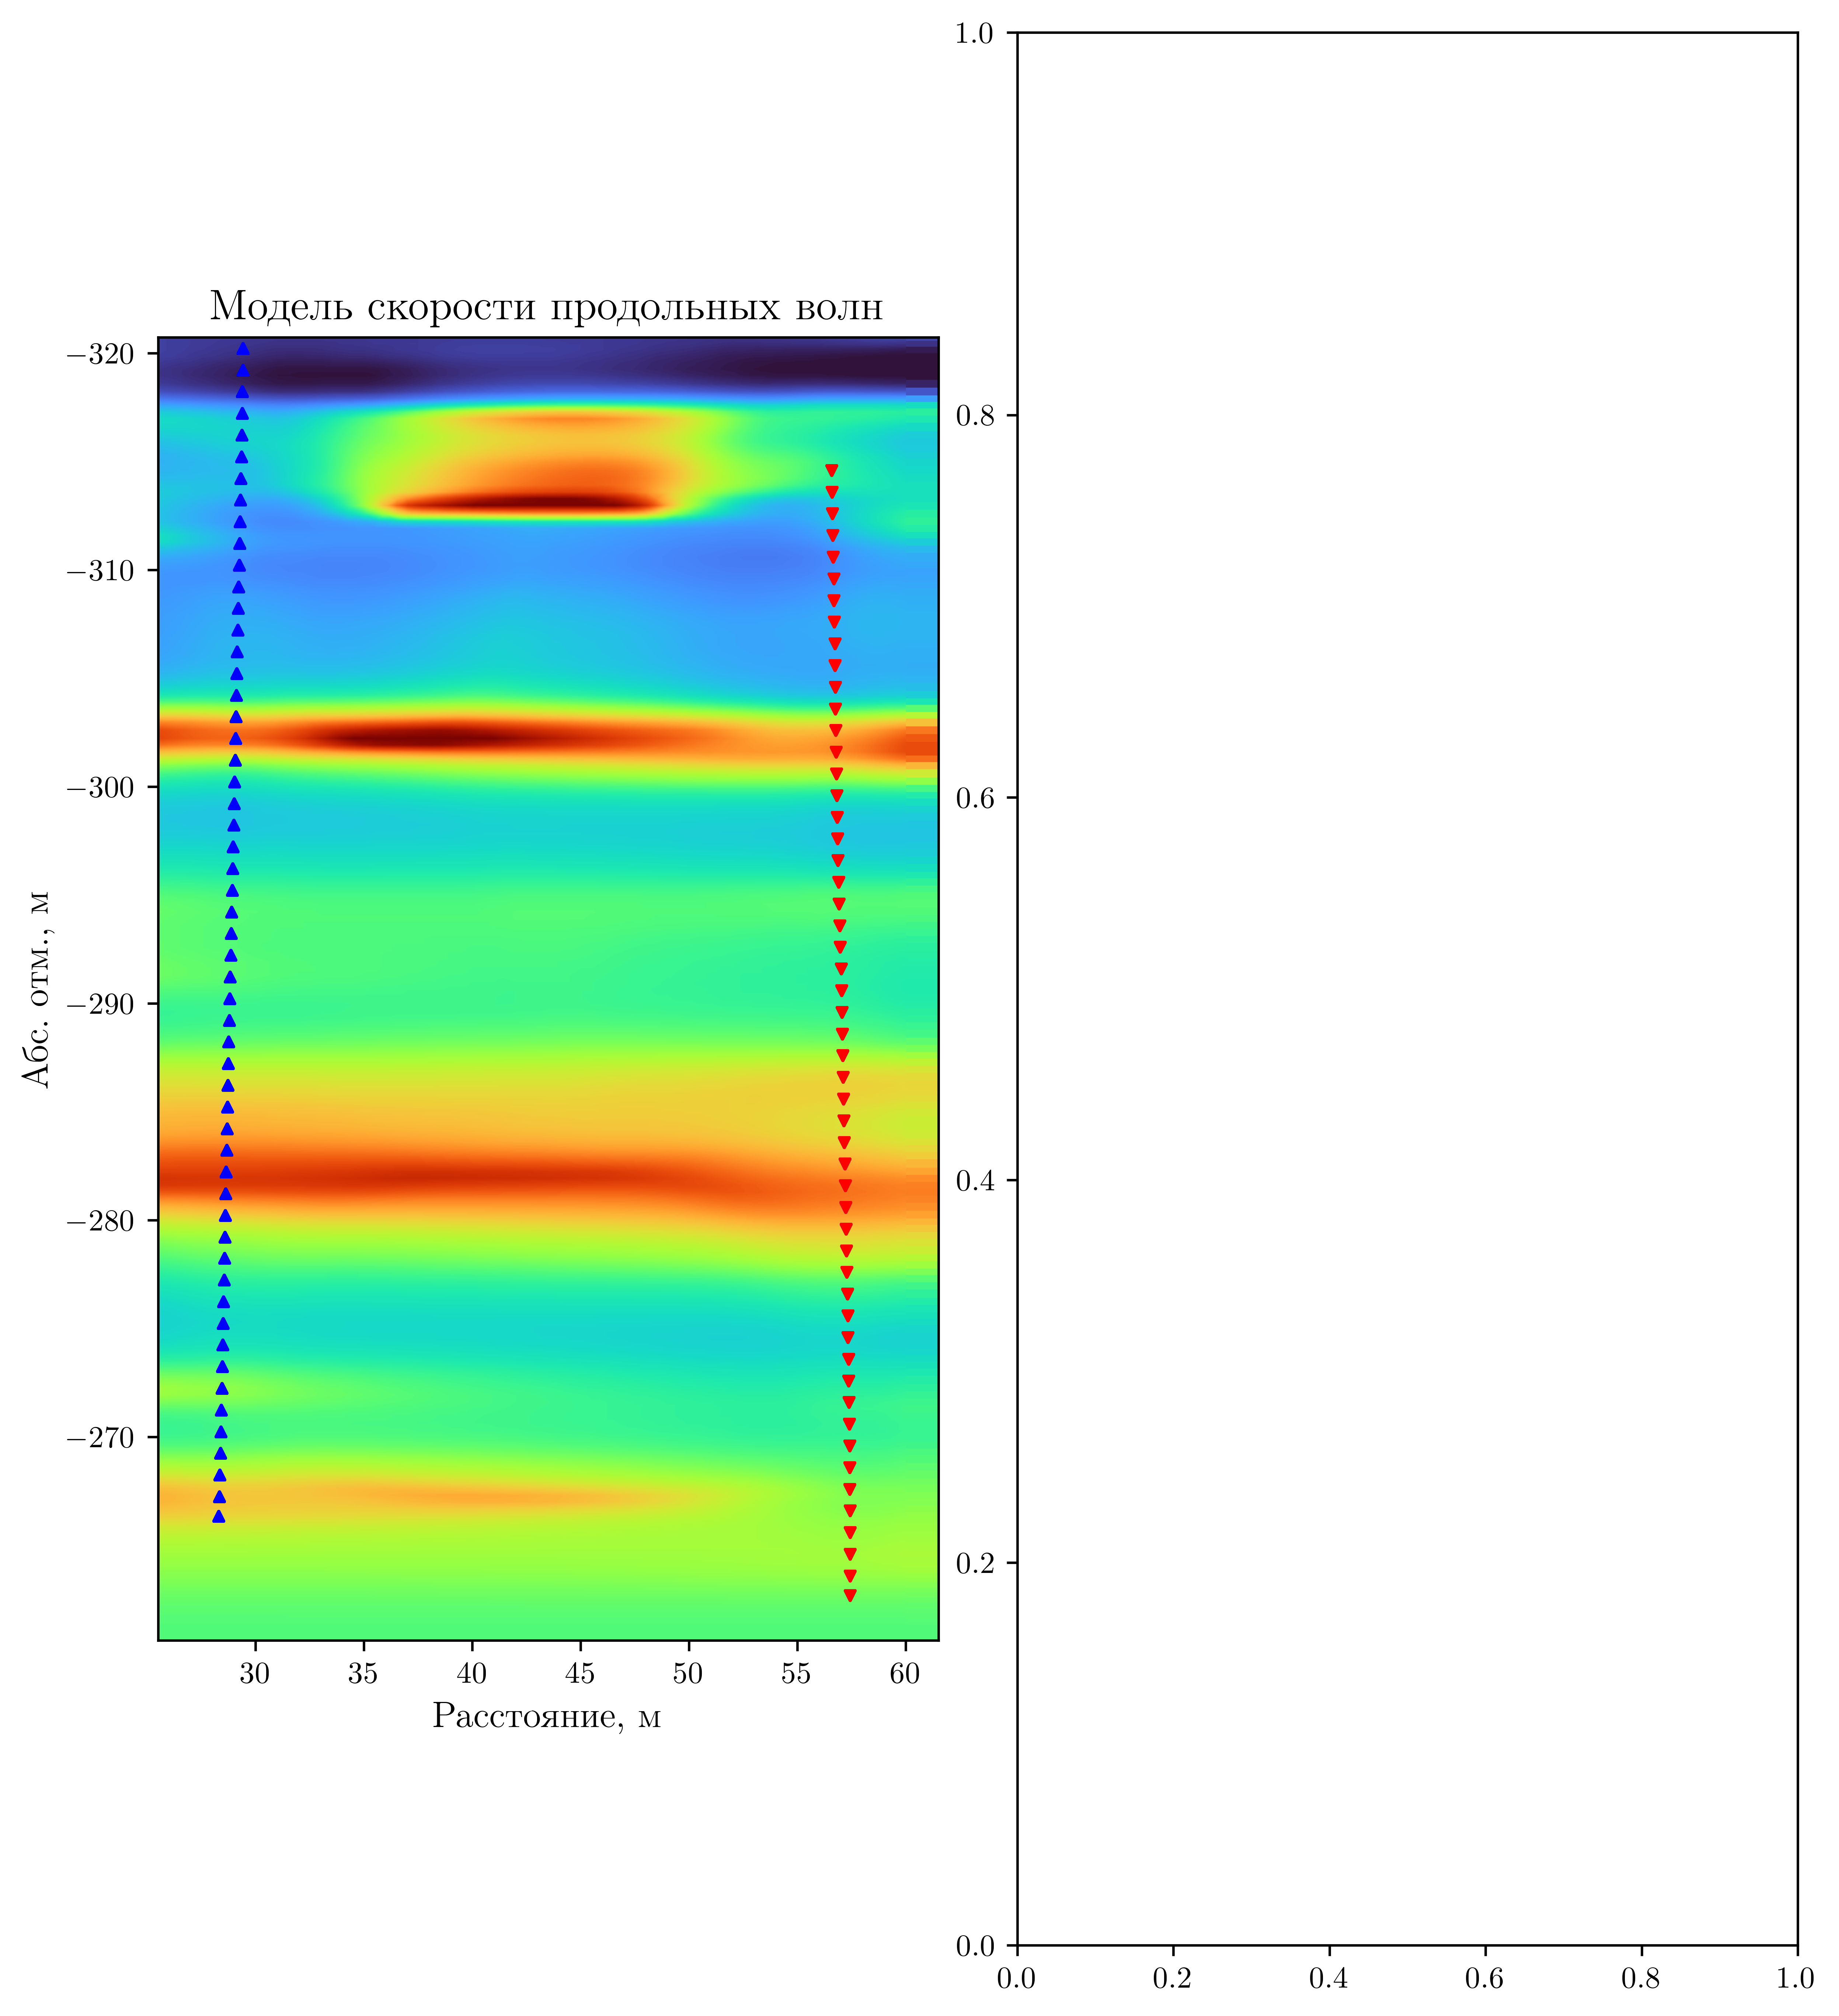

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(8.2, 9), dpi=600, constrained_layout=True)
velmodel.plot_vp(show=False, axs=axs[0])

# axs[0].imshow(layered, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)
# im1 = axs[1].imshow(layered_gal, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)

axs[0].scatter(dataset.x_coords, dataset.elevations, c='r', s=10, marker='v', zorder=50)
axs[0].scatter(dataset.opposite_x, dataset.opposite_elev, c='b', s=10, marker='^', zorder=50)


axs[0].set_xlabel("Расстояние, м")
plt.show()

In [17]:
from devito import mmin
print(velmodel.vp.min())
print(mmin(model.vp))

0.41999999999999993
0.6000000238418579


In [18]:
print(0.6/10/2000*1000)

0.03


In [19]:
print(model.critical_dt)

0.002822


In [20]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]
t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

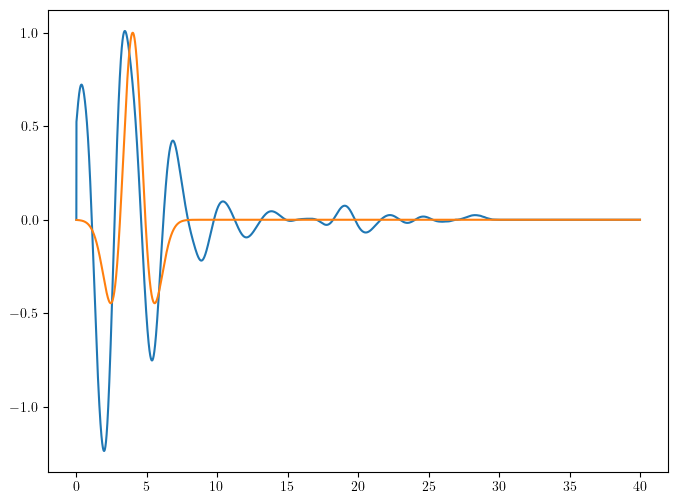

In [22]:
plt.plot(geometry.time_axis.time_values, srca.data[:]*500000)
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [23]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [24]:
500000/5000

100.0

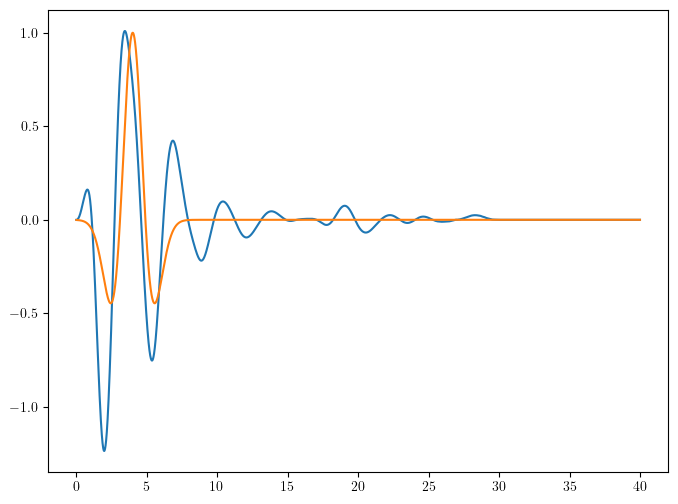

In [28]:
plt.plot(geometry.time_axis.time_values, left_taper_tukey(srca.data[:].reshape(-1)*500000, alpha=0.05)[0])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

Estimated gather centroid frequency: 261.93 Hz, Wavelet length: 3.82 ms
Scale:  4.704862241452352 0.00016179781935011728 0.00013845375242954377
Iter 0: Alpha = 3030073.341885886 Misfit = 3.5940e+05
Scale:  8.269020508494254 0.00016179781935011728 0.00014080354256321246
Iter 1: Alpha = 1939258.7508856654 Misfit = 5.0163e+04
Scale:  10.846541010921719 0.00016179781935011728 0.00013470372645141092
Iter 2: Alpha = 1058269.2773326181 Misfit = 1.4582e+04
Scale:  13.326234616930085 0.00016179781935011728 0.00014634411871181183
Iter 3: Alpha = 1061672.80371801 Misfit = 7.5035e+03
Scale:  15.366271463319706 0.00016179781935011728 0.00012980894738131942
Iter 4: Alpha = 736774.4967403344 Misfit = 3.7378e+03


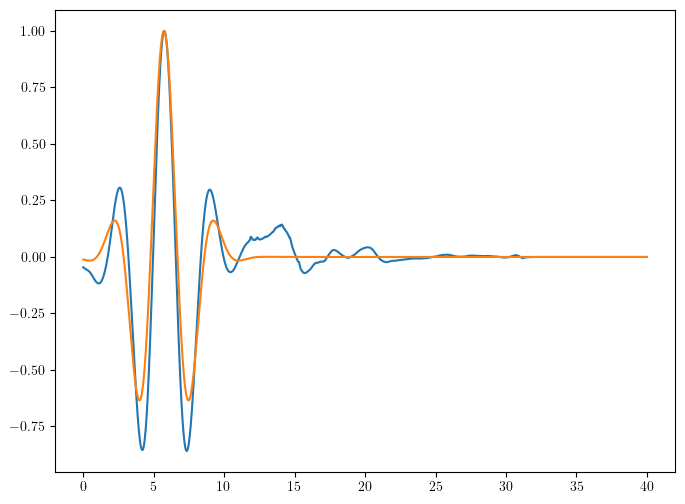

Estimated gather centroid frequency: 301.97 Hz, Wavelet length: 3.31 ms
Scale:  9.743961076299 0.00030211806309360514 0.00034941593647488527
Iter 0: Alpha = 806687.6200342412 Misfit = 2.7041e+05
Scale:  17.197984825549753 0.00030211806309360514 0.00037979815732425794
Iter 1: Alpha = 376179.02108297584 Misfit = 2.9064e+04
Scale:  22.373459240835643 0.00030211806309360514 0.00028493256421470767
Iter 2: Alpha = 162376.25327195943 Misfit = 7.2277e+03
Scale:  29.92145345116992 0.00030211806309360514 0.0003778833328004508
Iter 3: Alpha = 223728.97514839532 Misfit = 3.3624e+03
Scale:  37.693438135246645 0.00030211806309360514 0.00026770188025642154
Iter 4: Alpha = 94100.6240687577 Misfit = 9.2635e+02


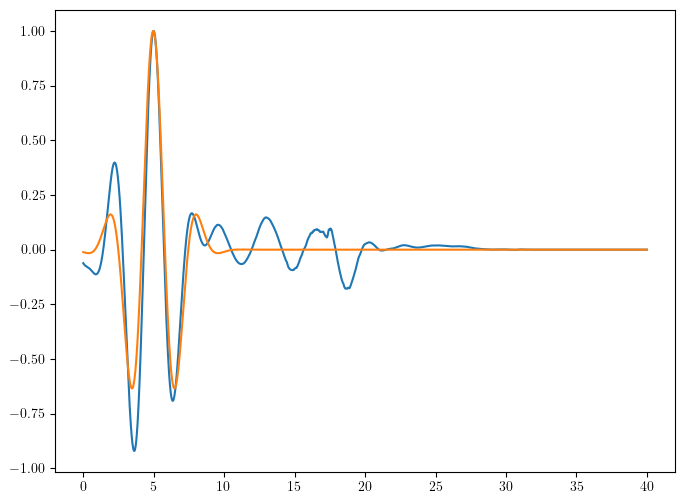

Estimated gather centroid frequency: 291.23 Hz, Wavelet length: 3.43 ms
Scale:  10.13786264380966 0.0003448515256200311 0.0004397846637120691
Iter 0: Alpha = 542945.7404136083 Misfit = 2.9071e+05
Scale:  17.697972990985352 0.0003448515256200311 0.0004685212506427558
Iter 1: Alpha = 262606.21595283214 Misfit = 3.2266e+04
Scale:  23.806823474914843 0.0003448515256200311 0.0003861146617953331
Iter 2: Alpha = 112450.1381358566 Misfit = 7.3210e+03
Scale:  32.02283774575763 0.0003448515256200311 0.0004904684206722723
Iter 3: Alpha = 147044.69254765083 Misfit = 3.1964e+03
Scale:  41.44814110479224 0.0003448515256200311 0.00037664204169540473
Iter 4: Alpha = 61933.174021609375 Misfit = 8.1635e+02


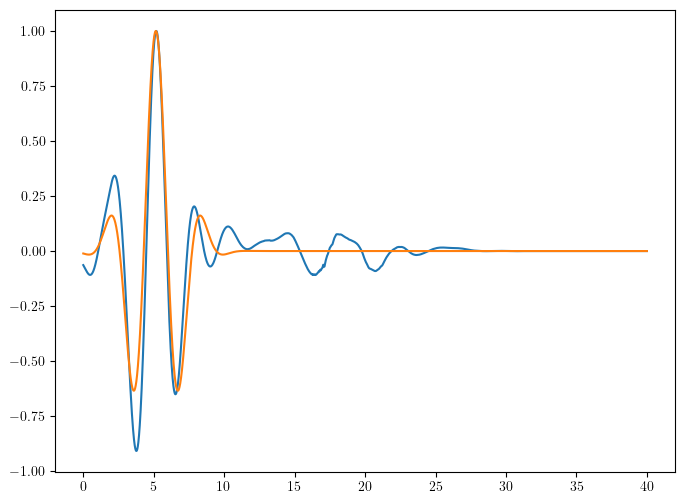

Estimated gather centroid frequency: 291.07 Hz, Wavelet length: 3.44 ms
Scale:  14.01922754227466 0.0005192234437663389 0.0006664334445410394
Iter 0: Alpha = 347303.62992244674 Misfit = 2.9104e+05
Scale:  22.323359136054947 0.0005192234437663389 0.000662812728628101
Iter 1: Alpha = 148163.3131704941 Misfit = 4.8908e+04
Scale:  26.679942524744387 0.0005192234437663389 0.0006262375576985848
Iter 2: Alpha = 78642.67316896752 Misfit = 1.9419e+04
Scale:  34.15707333276199 0.0005192234437663389 0.0006701760647453991
Iter 3: Alpha = 118843.86744839436 Misfit = 1.0734e+04
Scale:  38.92964470773629 0.0005192234437663389 0.0005594921052442715
Iter 4: Alpha = 43321.778900540376 Misfit = 3.8526e+03


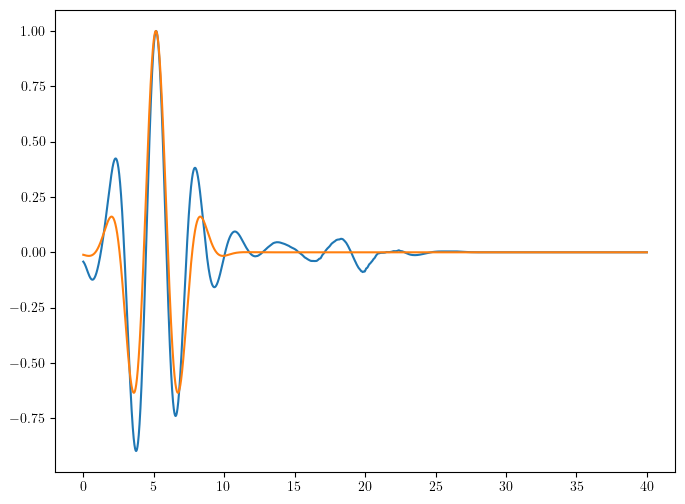

Estimated gather centroid frequency: 280.52 Hz, Wavelet length: 3.56 ms
Scale:  14.070960853071668 0.0005202191873184765 0.0006880974926075087
Iter 0: Alpha = 313732.8991334133 Misfit = 3.1335e+05
Scale:  22.009917287262756 0.0005202191873184765 0.0006592158545580588
Iter 1: Alpha = 119588.42886309687 Misfit = 5.3219e+04
Scale:  25.650588841966094 0.0005202191873184765 0.0006466352444662684
Iter 2: Alpha = 73152.27755434475 Misfit = 2.3622e+04
Scale:  32.287903439265634 0.0005202191873184765 0.0006995350058429978
Iter 3: Alpha = 92884.87356736988 Misfit = 1.3111e+04
Scale:  35.613563342287684 0.0005202191873184765 0.00058193560130923
Iter 4: Alpha = 42986.85975044762 Misfit = 5.6700e+03


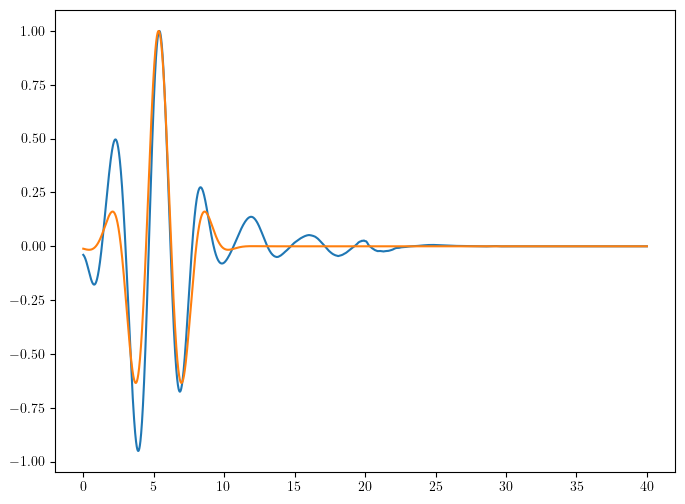

Estimated gather centroid frequency: 321.15 Hz, Wavelet length: 3.11 ms
Scale:  18.64612553694131 0.0006056371438295934 0.0007003090509548834
Iter 0: Alpha = 311146.5592074318 Misfit = 2.3907e+05
Scale:  28.694498847370628 0.0006056371438295934 0.0006845975704517232
Iter 1: Alpha = 59328.47673153008 Misfit = 2.9594e+04
Scale:  35.303584808063924 0.0006056371438295934 0.0006921223022395471
Iter 2: Alpha = 77964.46502151036 Misfit = 1.8035e+04
Scale:  37.6107874279217 0.0006056371438295934 0.0006673844779827343
Iter 3: Alpha = 37180.210731816376 Misfit = 8.8677e+03
Scale:  49.366101134126794 0.0006056371438295934 0.0007325654381552991
Iter 4: Alpha = 91386.46800373778 Misfit = 5.8435e+03


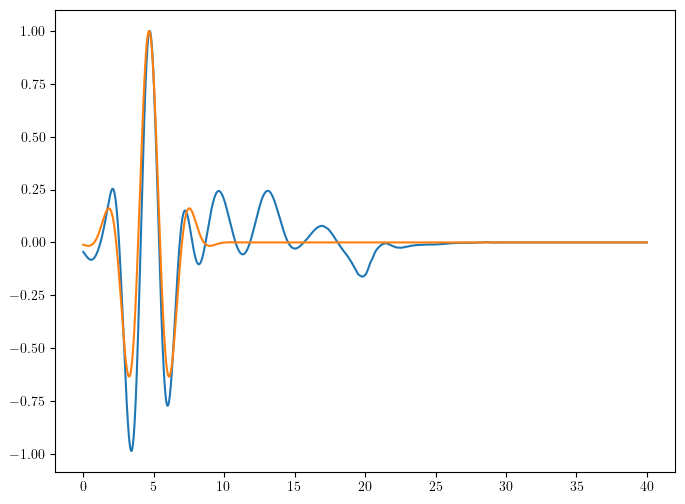

Estimated gather centroid frequency: 351.04 Hz, Wavelet length: 2.85 ms
Scale:  17.701319924988255 0.0005213421056841544 0.0005309586694703544
Iter 0: Alpha = 270912.4348216535 Misfit = 2.0009e+05
Scale:  27.583986541295918 0.0005213421056841544 0.0004856024804471223
Iter 1: Alpha = 46289.898519225644 Misfit = 2.4753e+04
Scale:  32.41141967698655 0.0005213421056841544 0.0005096786434267561
Iter 2: Alpha = 52977.32216305709 Misfit = 1.6137e+04
Scale:  34.6485464251765 0.0005213421056841544 0.0004976002704110763
Iter 3: Alpha = 31935.585898690468 Misfit = 9.5293e+03
Scale:  42.690439745155935 0.0005213421056841544 0.0005274076458612529
Iter 4: Alpha = 55866.00513815371 Misfit = 6.6018e+03


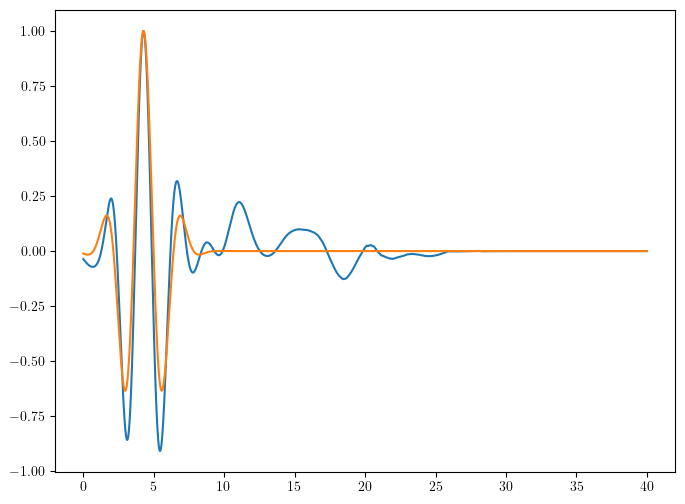

Estimated gather centroid frequency: 343.83 Hz, Wavelet length: 2.91 ms
Scale:  21.472548491696394 0.0006135755742220808 0.000654210486496065
Iter 0: Alpha = 251454.99995329016 Misfit = 2.0857e+05
Scale:  30.951190976154948 0.0006135755742220808 0.0005505092042822385
Iter 1: Alpha = 30830.6252919793 Misfit = 2.4380e+04
Scale:  40.652857326036525 0.0006135755742220808 0.0006370758550336708
Iter 2: Alpha = 99257.22646611721 Misfit = 1.7124e+04
Scale:  39.18281510968807 0.0006135755742220808 0.000520476203973137
Iter 3: Alpha = 15804.945383466178 Misfit = 4.9417e+03
Scale:  60.19745949948143 0.0006135755742220808 0.0006503726063919065
Iter 4: Alpha = 59121.827627247025 Misfit = 3.6068e+03


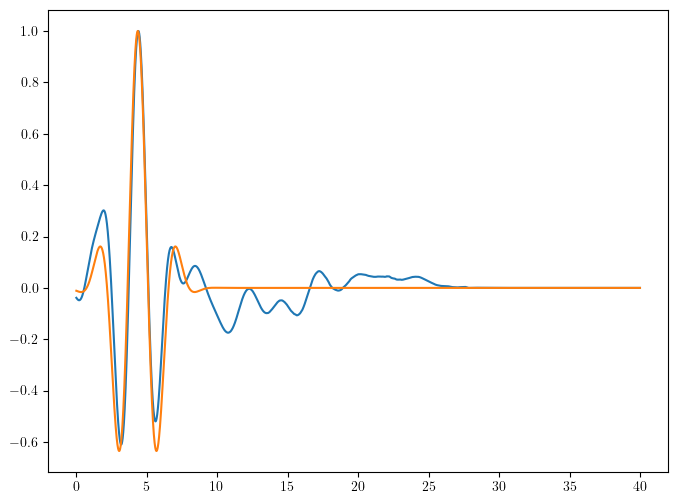

Estimated gather centroid frequency: 356.62 Hz, Wavelet length: 2.80 ms
Scale:  28.870362348591396 0.0008189105847169414 0.0007196371766263813
Iter 0: Alpha = 204429.3912368728 Misfit = 1.9388e+05
Scale:  37.20478756744968 0.0008189105847169414 0.0005556658814235377
Iter 1: Alpha = 25846.87552794689 Misfit = 3.5501e+04
Scale:  49.767667387209066 0.0008189105847169414 0.0006731033667293024
Iter 2: Alpha = 97801.82714755606 Misfit = 2.6679e+04
Scale:  47.059769340485985 0.0008189105847169414 0.0005751349207490003
Iter 3: Alpha = 14148.524151053089 Misfit = 8.6166e+03
Scale:  71.45170987215292 0.0008189105847169414 0.0006796317939891992
Iter 4: Alpha = 66248.32198100799 Misfit = 6.7190e+03


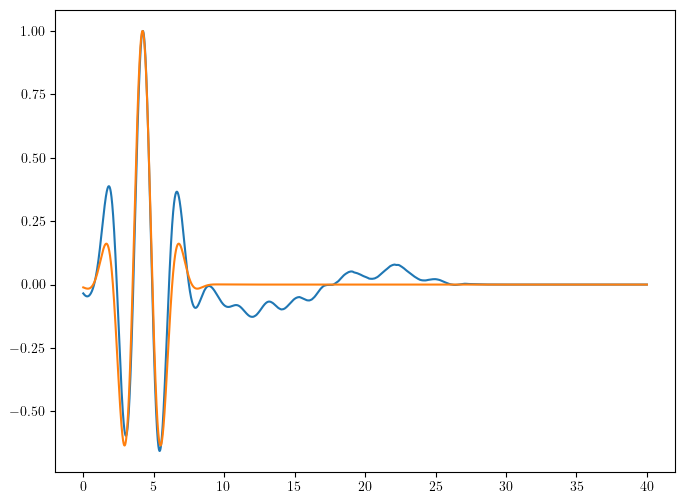

Estimated gather centroid frequency: 330.59 Hz, Wavelet length: 3.02 ms
Scale:  21.72734337931025 0.0006804590673189742 0.000751896694153276
Iter 0: Alpha = 180832.11257817928 Misfit = 2.2562e+05
Scale:  34.90712760405369 0.0006804590673189742 0.0007167340105092294
Iter 1: Alpha = 62716.9132907142 Misfit = 3.4627e+04
Scale:  38.47278294863402 0.0006804590673189742 0.0005925418439892228
Iter 2: Alpha = 28497.09809239606 Misfit = 1.5811e+04
Scale:  51.30903632632447 0.0006804590673189742 0.0007884568529057817
Iter 3: Alpha = 72989.43297053142 Misfit = 1.0185e+04
Scale:  53.87211139939222 0.0006804590673189742 0.00046908829879469406
Iter 4: Alpha = 14317.100995145156 Misfit = 2.8714e+03


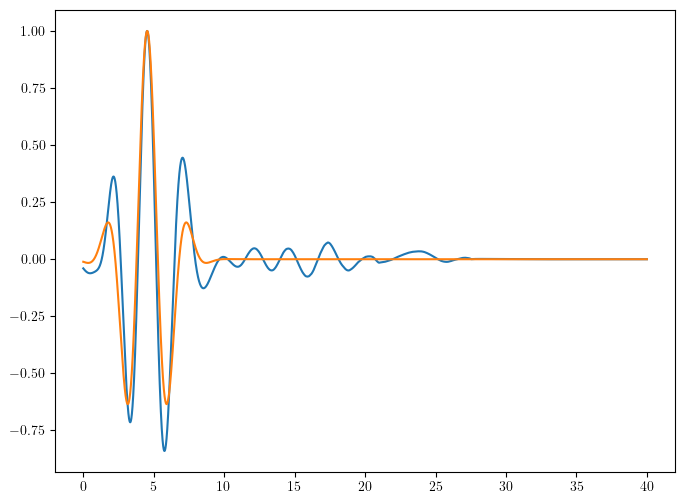

Estimated gather centroid frequency: 353.43 Hz, Wavelet length: 2.83 ms
Scale:  32.34618034953315 0.0009531164704690849 0.0009974000887961695
Iter 0: Alpha = 157532.43478972482 Misfit = 1.9739e+05
Scale:  50.142613530857005 0.0009531164704690849 0.0009108986420771651
Iter 1: Alpha = 38771.08636761753 Misfit = 2.7612e+04
Scale:  57.56556728152473 0.0009531164704690849 0.000825454803582078
Iter 2: Alpha = 26548.784007527887 Misfit = 1.5077e+04
Scale:  69.51831838664765 0.0009531164704690849 0.0009758818897028063
Iter 3: Alpha = 36649.0459968631 Misfit = 9.4158e+03
Scale:  72.17554865054018 0.0009531164704690849 0.0007267012298491958
Iter 4: Alpha = 15010.989255857325 Misfit = 4.5816e+03


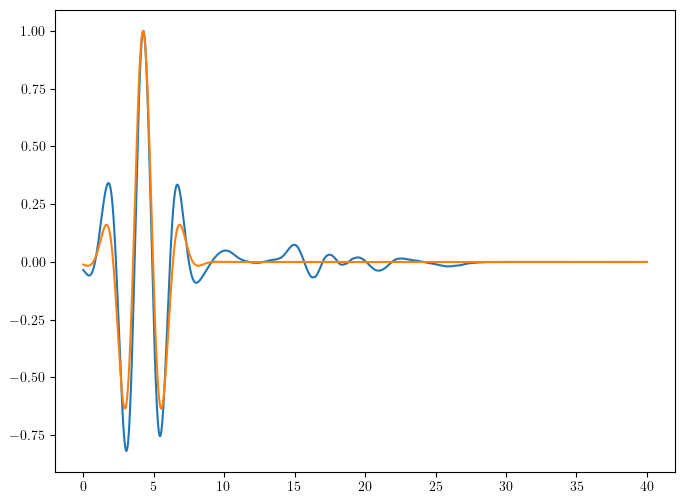

Estimated gather centroid frequency: 397.32 Hz, Wavelet length: 2.52 ms
Scale:  39.72126131933524 0.000574842536036392 0.0006793066579803663
Iter 0: Alpha = 257489.74193064542 Misfit = 1.5619e+05
Scale:  38.32202563730805 0.000574842536036392 0.00048210686156486816
Iter 1: Alpha = 24293.553100191857 Misfit = 5.5221e+04
Scale:  56.873851411584084 0.000574842536036392 0.000560454092322065
Iter 2: Alpha = 118941.11627894426 Misfit = 4.7766e+04
Scale:  50.858226876762544 0.000574842536036392 0.0005723497495440823
Iter 3: Alpha = 21512.839036506986 Misfit = 2.8195e+04
Scale:  69.79401850834716 0.000574842536036392 0.0006679164248955858
Iter 4: Alpha = 144582.749935818 Misfit = 2.4905e+04


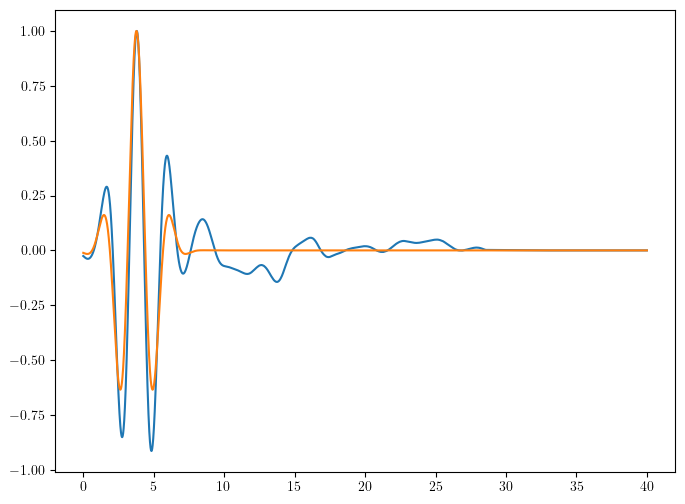

Estimated gather centroid frequency: 409.30 Hz, Wavelet length: 2.44 ms
Scale:  36.72244981091286 0.0005083890307102424 0.0005599674842908861
Iter 0: Alpha = 344426.0505140938 Misfit = 1.4718e+05
Scale:  31.740358521620728 0.0005083890307102424 0.00033177861767154376
Iter 1: Alpha = 29263.540334390887 Misfit = 5.6966e+04
Scale:  48.809637186581476 0.0005083890307102424 0.0004148647880089095
Iter 2: Alpha = 111532.5677753596 Misfit = 5.0323e+04
Scale:  41.436453655595194 0.0005083890307102424 0.0004863904962211749
Iter 3: Alpha = 25268.60381002237 Misfit = 3.6469e+04
Scale:  58.475723299359025 0.0005083890307102424 0.0005511736279185748
Iter 4: Alpha = 226221.70067545574 Misfit = 3.3270e+04


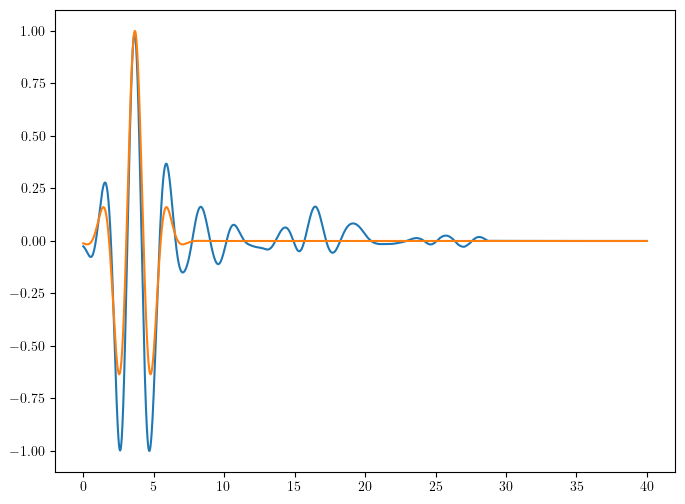

Estimated gather centroid frequency: 427.03 Hz, Wavelet length: 2.34 ms
Scale:  35.75534957367921 0.0005858144974227596 0.000756048773364063
Iter 0: Alpha = 287720.4863750771 Misfit = 1.3522e+05
Scale:  41.932882315680544 0.0005858144974227596 0.00039246642313668596
Iter 1: Alpha = 33374.528450064245 Misfit = 3.4858e+04
Scale:  53.50400800092214 0.0005858144974227596 0.0006445671357173183
Iter 2: Alpha = 143707.88345308026 Misfit = 2.8778e+04
Scale:  48.09754241072592 0.0005858144974227596 0.00041799047617248683
Iter 3: Alpha = 20931.368116312788 Misfit = 1.3947e+04
Scale:  67.13442473033824 0.0005858144974227596 0.0006563005998067203
Iter 4: Alpha = 111907.65680398134 Misfit = 1.1924e+04


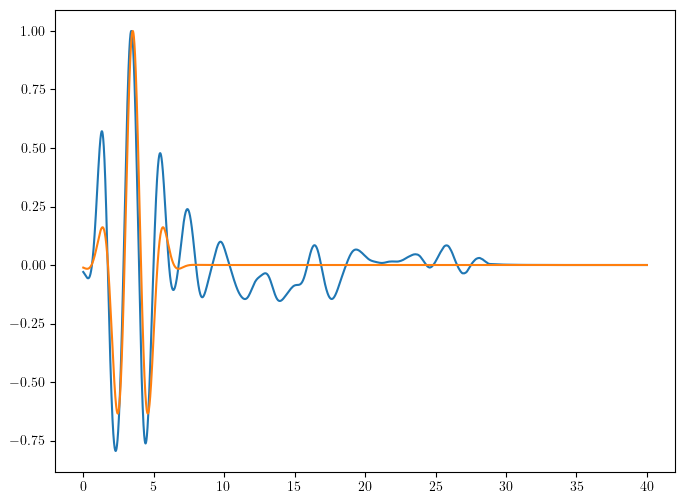

Estimated gather centroid frequency: 368.10 Hz, Wavelet length: 2.72 ms
Scale:  26.008435878190653 0.0006651369296192275 0.0008424007100932778
Iter 0: Alpha = 179378.96263395587 Misfit = 1.8198e+05
Scale:  41.68217699138434 0.0006651369296192275 0.0006660467734296662
Iter 1: Alpha = 87517.60399268674 Misfit = 2.7319e+04
Scale:  47.17621636749504 0.0006651369296192275 0.0007385846630031207
Iter 2: Alpha = 28895.903221507015 Misfit = 9.0459e+03
Scale:  63.72454307142312 0.0006651369296192275 0.0007205545063391373
Iter 3: Alpha = 80063.66666092431 Misfit = 5.8199e+03
Scale:  78.53175084316844 0.0006651369296192275 0.0007089149383273677
Iter 4: Alpha = 19087.825509083006 Misfit = 1.5092e+03


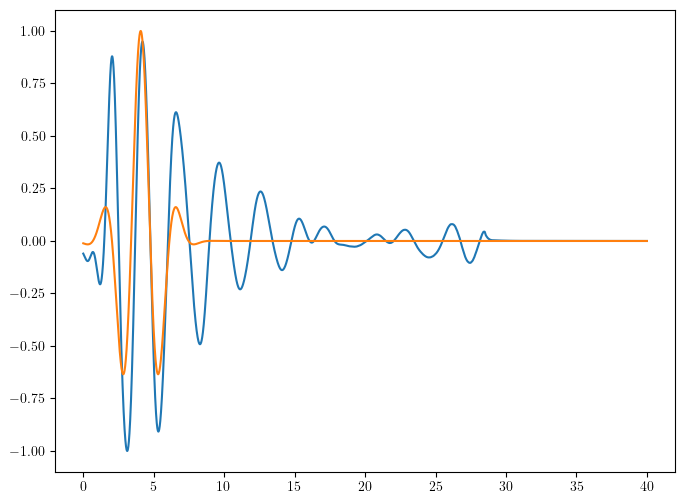

Estimated gather centroid frequency: 371.45 Hz, Wavelet length: 2.69 ms
Scale:  31.464951001083925 0.0011404363761856138 0.0012906191739218197
Iter 0: Alpha = 103273.31338017153 Misfit = 1.7871e+05
Scale:  44.482578875122805 0.0011404363761856138 0.0011101565072368076
Iter 1: Alpha = 82709.5555396528 Misfit = 4.9517e+04
Scale:  55.69598760467298 0.0011404363761856138 0.0012594647935484406
Iter 2: Alpha = 34068.93554012851 Misfit = 1.6820e+04
Scale:  64.23058742522937 0.0011404363761856138 0.0010466478218707886
Iter 3: Alpha = 43043.37300952354 Misfit = 1.0642e+04
Scale:  70.19565109648912 0.0011404363761856138 0.0012175542182456037
Iter 4: Alpha = 19663.030003479544 Misfit = 5.8156e+03


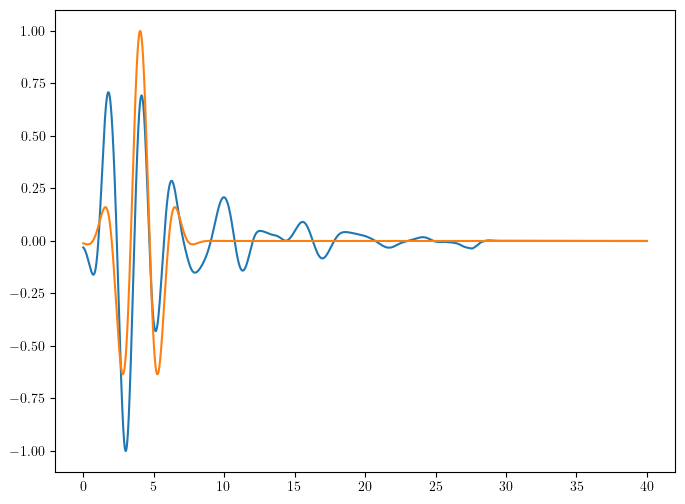

Estimated gather centroid frequency: 335.66 Hz, Wavelet length: 2.98 ms
Scale:  32.47368112152071 0.001208520060334008 0.001625177168365036
Iter 0: Alpha = 80760.11524565225 Misfit = 2.1885e+05
Scale:  44.29234113777806 0.001208520060334008 0.0013044474163447636
Iter 1: Alpha = 71852.38073427006 Misfit = 7.4766e+04
Scale:  54.54458289454703 0.001208520060334008 0.0014579475406649352
Iter 2: Alpha = 38786.8898365801 Misfit = 2.7715e+04
Scale:  62.211740793352206 0.001208520060334008 0.0011628478637418038
Iter 3: Alpha = 32919.25820623332 Misfit = 1.5825e+04
Scale:  69.86651186491775 0.001208520060334008 0.0014655780374693372
Iter 4: Alpha = 25382.18619352798 Misfit = 9.3859e+03


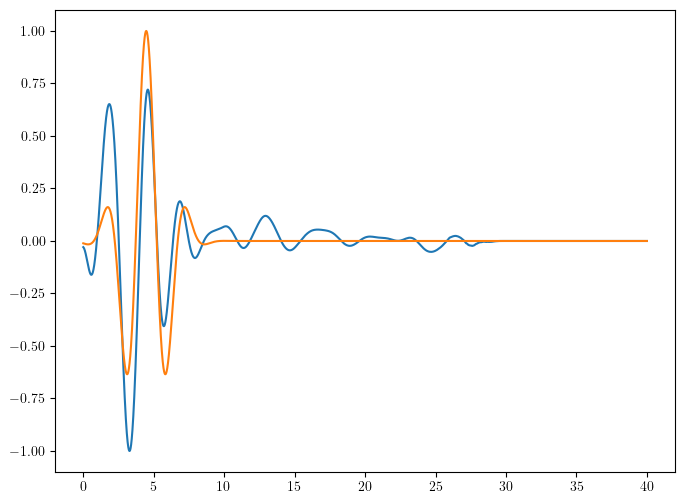

Estimated gather centroid frequency: 365.62 Hz, Wavelet length: 2.74 ms
Scale:  58.606134412546155 0.0018135471343179936 0.0020951023210379503
Iter 0: Alpha = 54405.98540053457 Misfit = 1.8445e+05
Scale:  79.83555551557696 0.0018135471343179936 0.0014082032731900223
Iter 1: Alpha = 35559.483871730554 Misfit = 5.6768e+04
Scale:  86.12803011901326 0.0018135471343179936 0.0017480295896138386
Iter 2: Alpha = 14260.81373064393 Misfit = 2.6079e+04
Scale:  106.43609184848327 0.0018135471343179936 0.0016371628061401416
Iter 3: Alpha = 40453.308451302124 Misfit = 1.8463e+04
Scale:  113.95193175894754 0.0018135471343179936 0.0018481613948562795
Iter 4: Alpha = 8161.276509639522 Misfit = 6.2889e+03


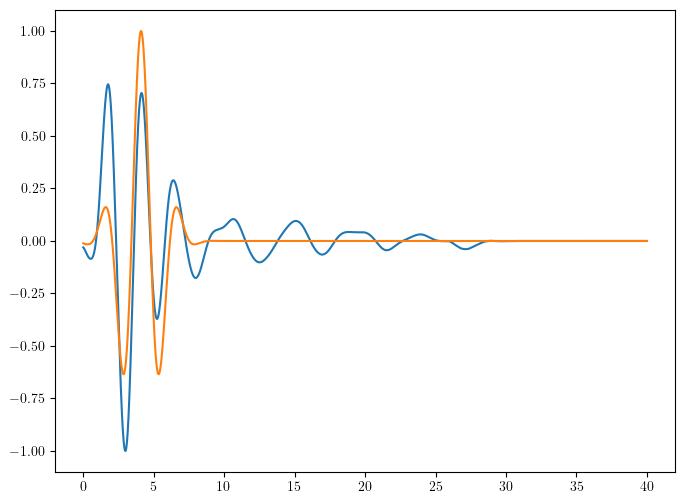

Estimated gather centroid frequency: 354.39 Hz, Wavelet length: 2.82 ms
Scale:  50.21396025434267 0.0016041177147032007 0.00190019983429294
Iter 0: Alpha = 72955.97824833036 Misfit = 1.9633e+05
Scale:  74.59355677463165 0.0016041177147032007 0.001284493026626386
Iter 1: Alpha = 28645.933297207634 Misfit = 3.4683e+04
Scale:  85.08580871920586 0.0016041177147032007 0.0016780104465531354
Iter 2: Alpha = 16074.637806573015 Misfit = 1.5707e+04
Scale:  106.52539144200317 0.0016041177147032007 0.0013613056982101069
Iter 3: Alpha = 25945.890540909822 Misfit = 9.4403e+03
Scale:  114.50541226399505 0.0016041177147032007 0.0015899496235712912
Iter 4: Alpha = 8909.687878514434 Misfit = 3.7459e+03


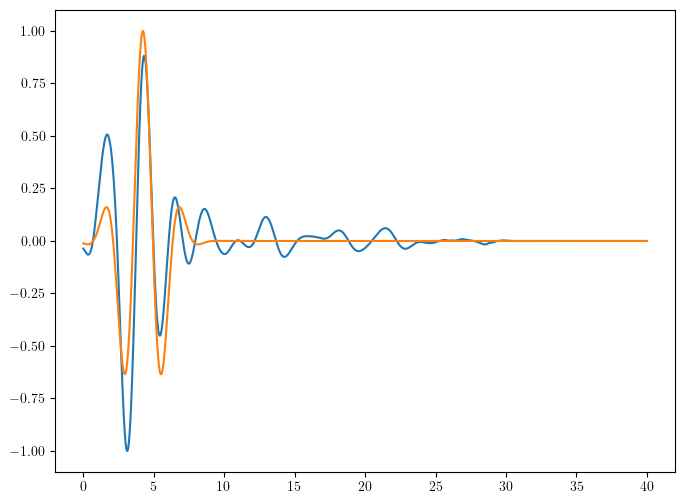

Estimated gather centroid frequency: 334.50 Hz, Wavelet length: 2.99 ms
Scale:  58.04765921344901 0.0018590123774089628 0.0022847063632941583
Iter 0: Alpha = 58876.75522447818 Misfit = 2.2036e+05
Scale:  83.92575964378852 0.0018590123774089628 0.0017714106334532236
Iter 1: Alpha = 24815.507788921153 Misfit = 4.5504e+04
Scale:  96.35208715254589 0.0018590123774089628 0.0022933908017172397
Iter 2: Alpha = 14773.734702830563 Misfit = 2.1901e+04
Scale:  117.67593120385719 0.0018590123774089628 0.0018823120880703426
Iter 3: Alpha = 21200.941253134915 Misfit = 1.3487e+04
Scale:  126.94619679313838 0.0018590123774089628 0.0022086769776196065
Iter 4: Alpha = 8846.297932260157 Misfit = 6.5107e+03


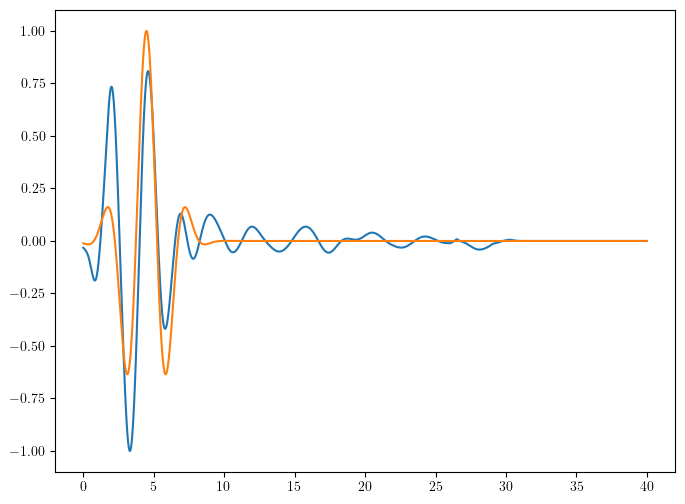

Estimated gather centroid frequency: 339.05 Hz, Wavelet length: 2.95 ms
Scale:  55.59466669469219 0.0019332079701214777 0.0023257364945103135
Iter 0: Alpha = 60405.89487922473 Misfit = 2.1449e+05
Scale:  75.80097604571311 0.0019332079701214777 0.001869192729301285
Iter 1: Alpha = 27540.229169057857 Misfit = 5.9074e+04
Scale:  84.91831694288355 0.0019332079701214777 0.0022420146399172356
Iter 2: Alpha = 16829.183428884568 Misfit = 3.2338e+04
Scale:  99.9602365452141 0.0019332079701214777 0.0018953655029212287
Iter 3: Alpha = 24867.696533199734 Misfit = 2.1816e+04
Scale:  105.3901533720779 0.0019332079701214777 0.002062461093588482
Iter 4: Alpha = 10394.32292075239 Misfit = 1.2041e+04


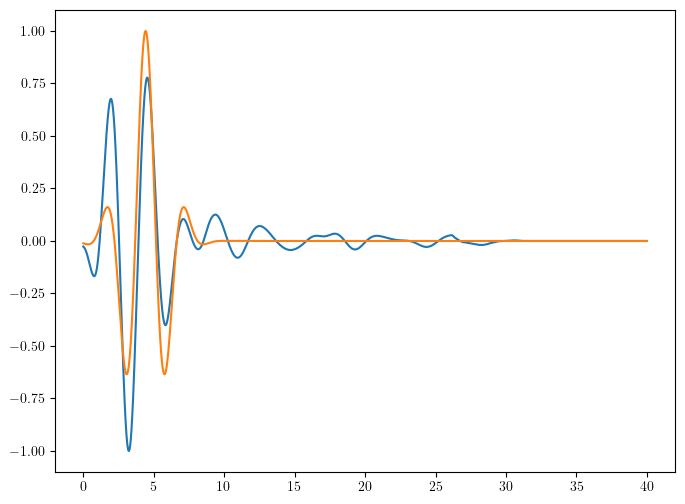

Estimated gather centroid frequency: 314.11 Hz, Wavelet length: 3.18 ms
Scale:  53.70066233418155 0.0021214532103726335 0.002525604672491236
Iter 0: Alpha = 56729.29757954507 Misfit = 2.4990e+05
Scale:  70.7989860459352 0.0021214532103726335 0.0020177034018333513
Iter 1: Alpha = 28366.703430267626 Misfit = 7.9630e+04
Scale:  81.00211688274591 0.0021214532103726335 0.0023831631628749065
Iter 2: Alpha = 20688.343082475025 Misfit = 4.3590e+04
Scale:  92.54156885261062 0.0021214532103726335 0.001912534483688029
Iter 3: Alpha = 20249.898935583562 Misfit = 2.7366e+04
Scale:  102.93939960829624 0.0021214532103726335 0.00223082964276268
Iter 4: Alpha = 15483.847928205105 Misfit = 1.6740e+04


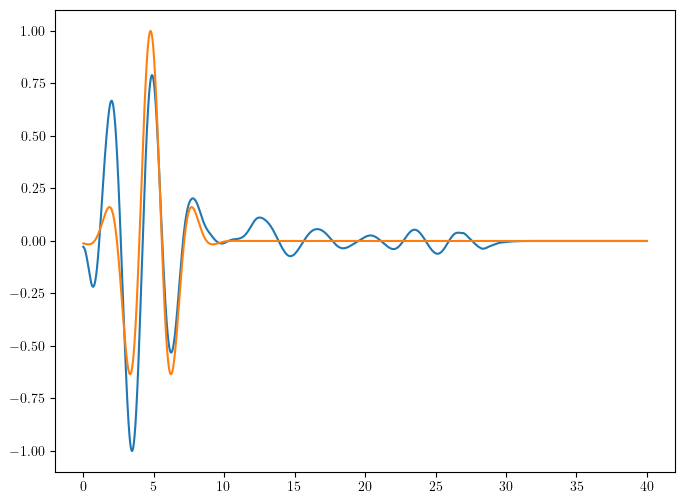

Estimated gather centroid frequency: 355.73 Hz, Wavelet length: 2.81 ms
Scale:  71.1362337765197 0.0025441094184954034 0.0030402822138267727
Iter 0: Alpha = 45999.47198395505 Misfit = 1.9485e+05
Scale:  101.27288012333162 0.0025441094184954034 0.0024420904187774095
Iter 1: Alpha = 22581.789799102713 Misfit = 4.6029e+04
Scale:  114.90453952569769 0.0025441094184954034 0.0027417164263010647
Iter 2: Alpha = 11359.961089182421 Misfit = 2.1052e+04
Scale:  140.11946482955335 0.0025441094184954034 0.0024683285837382943
Iter 3: Alpha = 19964.104436732934 Misfit = 1.3543e+04
Scale:  152.30653796668327 0.0025441094184954034 0.002606938403904247
Iter 4: Alpha = 6686.103493157694 Misfit = 5.7628e+03


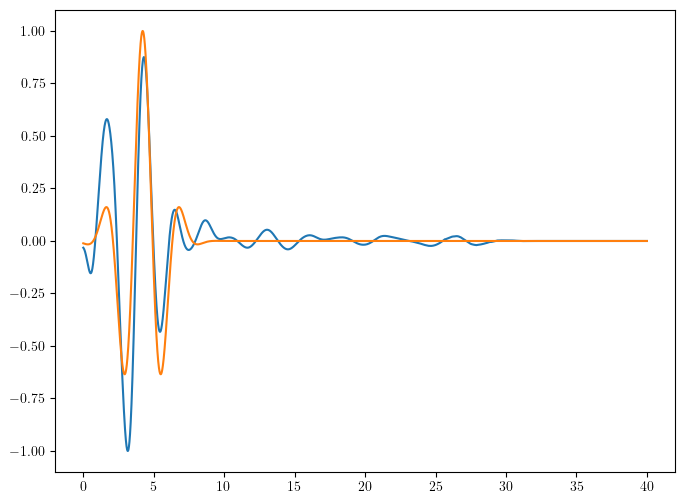

Estimated gather centroid frequency: 351.48 Hz, Wavelet length: 2.85 ms
Scale:  54.18089862796541 0.002009430949566138 0.002313451711825992
Iter 0: Alpha = 60867.87577527551 Misfit = 1.9959e+05
Scale:  77.45801209309192 0.002009430949566138 0.0018593195148824235
Iter 1: Alpha = 31269.796832174667 Misfit = 4.8425e+04
Scale:  87.77898075041867 0.002009430949566138 0.002091472127972631
Iter 2: Alpha = 15143.433789435114 Misfit = 2.1515e+04
Scale:  108.23666535138841 0.002009430949566138 0.0018893431051609834
Iter 3: Alpha = 26977.298932005666 Misfit = 1.3729e+04
Scale:  117.20038347377036 0.002009430949566138 0.0019685473878248
Iter 4: Alpha = 8852.440867789715 Misfit = 5.6389e+03


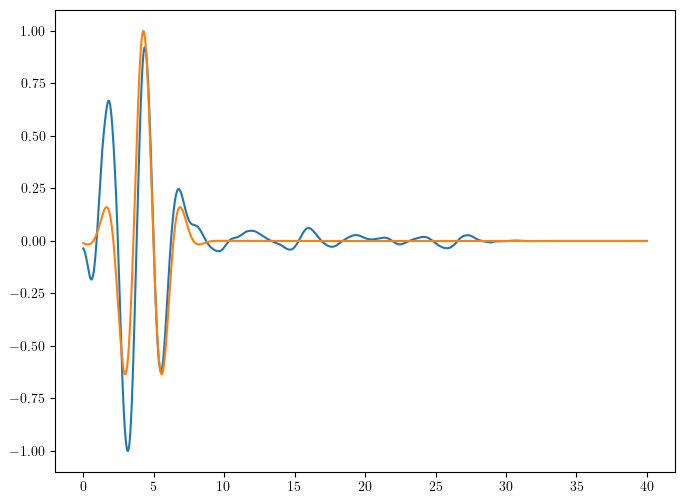

Estimated gather centroid frequency: 404.68 Hz, Wavelet length: 2.47 ms
Scale:  54.01253478325667 0.0016232156056573365 0.002042828451079239
Iter 0: Alpha = 69632.1852395516 Misfit = 1.5056e+05
Scale:  82.06317451098731 0.0016232156056573365 0.0015954572319849998
Iter 1: Alpha = 32837.35357418571 Misfit = 2.9365e+04
Scale:  88.6118851887345 0.0016232156056573365 0.0017561622871349568
Iter 2: Alpha = 12896.192509950964 Misfit = 1.2354e+04
Scale:  117.66878063694615 0.0016232156056573365 0.0017338912377753573
Iter 3: Alpha = 38792.821954578205 Misfit = 8.2716e+03
Scale:  134.16275969304047 0.0016232156056573365 0.0015705903944776179
Iter 4: Alpha = 7306.9777259877255 Misfit = 2.0328e+03


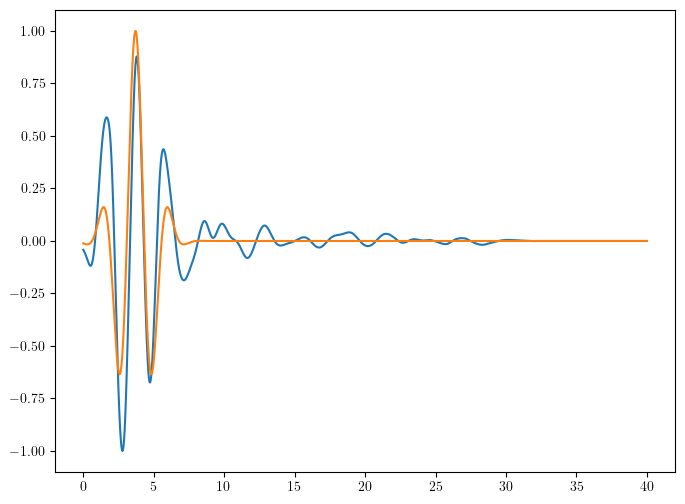

Estimated gather centroid frequency: 366.12 Hz, Wavelet length: 2.73 ms
Scale:  39.866818280658826 0.0012081968397256795 0.0015895819750771378
Iter 0: Alpha = 89004.9527739819 Misfit = 1.8394e+05
Scale:  62.392972757803136 0.0012081968397256795 0.001307022430744177
Iter 1: Alpha = 48110.96067681846 Misfit = 3.4658e+04
Scale:  72.9879332584483 0.0012081968397256795 0.0014177120489439641
Iter 2: Alpha = 17678.28037858015 Misfit = 1.1989e+04
Scale:  96.02346783741403 0.0012081968397256795 0.001368014892404942
Iter 3: Alpha = 41387.523686748726 Misfit = 7.5145e+03
Scale:  109.43927237679692 0.0012081968397256795 0.0012630165760975536
Iter 4: Alpha = 9812.835108253645 Misfit = 2.1899e+03


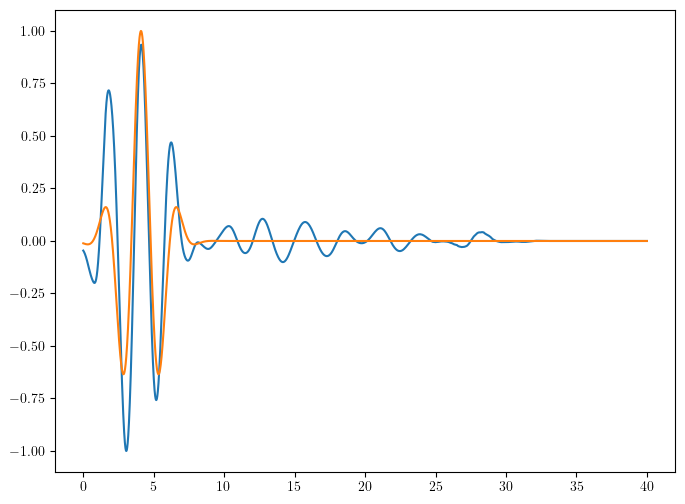

Estimated gather centroid frequency: 455.04 Hz, Wavelet length: 2.20 ms
Scale:  81.37668283583238 0.0021613099923954455 0.0027154926113820616
Iter 0: Alpha = 60507.12909068493 Misfit = 1.1908e+05
Scale:  138.35885739095878 0.0021613099923954455 0.0020474989173362938
Iter 1: Alpha = 23715.774374050423 Misfit = 1.4712e+04
Scale:  150.9568312898336 0.0021613099923954455 0.002102288958873992
Iter 2: Alpha = 7855.08176925778 Misfit = 5.1279e+03
Scale:  212.92803573334257 0.0021613099923954455 0.0022801297489702895
Iter 3: Alpha = 26727.87332169539 Misfit = 3.2899e+03
Scale:  301.4020972597037 0.0021613099923954455 0.0019831099797921513
Iter 4: Alpha = 5211.384377232978 Misfit = 4.7657e+02


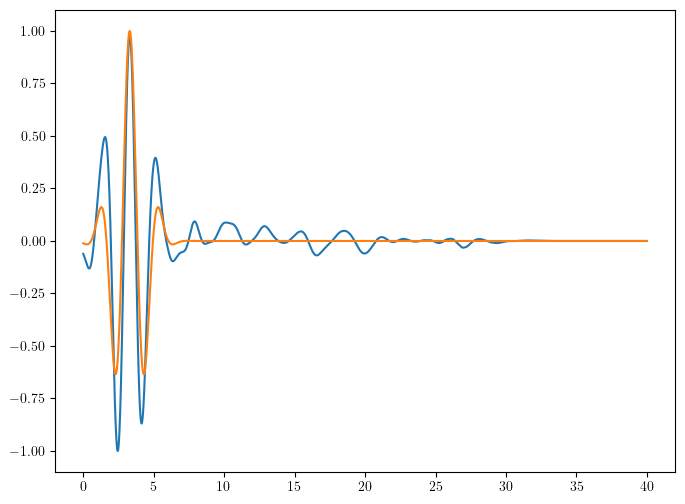

Estimated gather centroid frequency: 462.35 Hz, Wavelet length: 2.16 ms
Scale:  52.747691541607324 0.0012022904717549133 0.001595654957196682
Iter 0: Alpha = 118693.27927307782 Misfit = 1.1535e+05
Scale:  89.18889522439875 0.0012022904717549133 0.0011563828383015125
Iter 1: Alpha = 37637.91499775017 Misfit = 1.2861e+04
Scale:  94.28570803194795 0.0012022904717549133 0.0011881980511560248
Iter 2: Alpha = 13671.649340539281 Misfit = 5.2112e+03
Scale:  131.03949708166442 0.0012022904717549133 0.0013226221819401464
Iter 3: Alpha = 49499.32882847392 Misfit = 3.4308e+03
Scale:  171.523042007419 0.0012022904717549133 0.0010472012131552762
Iter 4: Alpha = 7562.234749221309 Misfit = 4.8756e+02


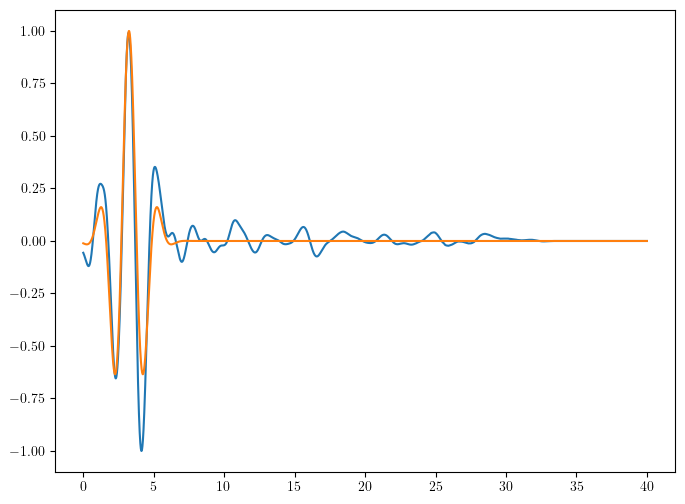

Estimated gather centroid frequency: 466.33 Hz, Wavelet length: 2.14 ms
Scale:  54.146244093785675 0.0011900680261406143 0.001469960970477915
Iter 0: Alpha = 124518.7478554118 Misfit = 1.1339e+05
Scale:  86.85742381755327 0.0011900680261406143 0.0010556060142022036
Iter 1: Alpha = 38097.31235737394 Misfit = 1.6518e+04
Scale:  90.54618635854249 0.0011900680261406143 0.0011064795779030473
Iter 2: Alpha = 15800.344407628552 Misfit = 8.1438e+03
Scale:  121.26201189629181 0.0011900680261406143 0.001200826420871605
Iter 3: Alpha = 55486.87512009497 Misfit = 5.7536e+03
Scale:  124.58409594708257 0.0011900680261406143 0.0009087855352577995
Iter 4: Alpha = 8281.973607411897 Misfit = 1.3660e+03


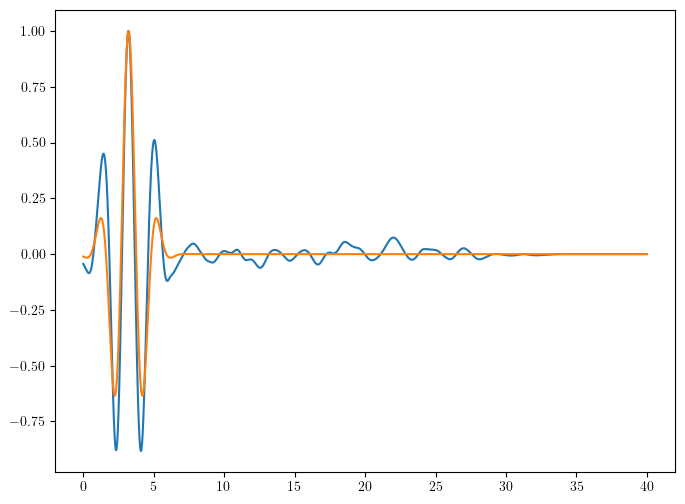

Estimated gather centroid frequency: 535.21 Hz, Wavelet length: 1.87 ms
Scale:  62.69017646947768 0.0011628997488818704 0.0014920101931331672
Iter 0: Alpha = 127034.42898435364 Misfit = 8.6079e+04
Scale:  103.14061190423993 0.0011628997488818704 0.0010692451175287566
Iter 1: Alpha = 36004.37062271221 Misfit = 1.1295e+04
Scale:  103.41281794320405 0.0011628997488818704 0.0011452486832106148
Iter 2: Alpha = 12824.448101573118 Misfit = 5.5806e+03
Scale:  141.50095998423234 0.0011628997488818704 0.0012554056334799202
Iter 3: Alpha = 59901.636361596684 Misfit = 4.1302e+03
Scale:  175.5255409867188 0.0011628997488818704 0.0010585487806670445
Iter 4: Alpha = 8063.5740478093285 Misfit = 7.2477e+02


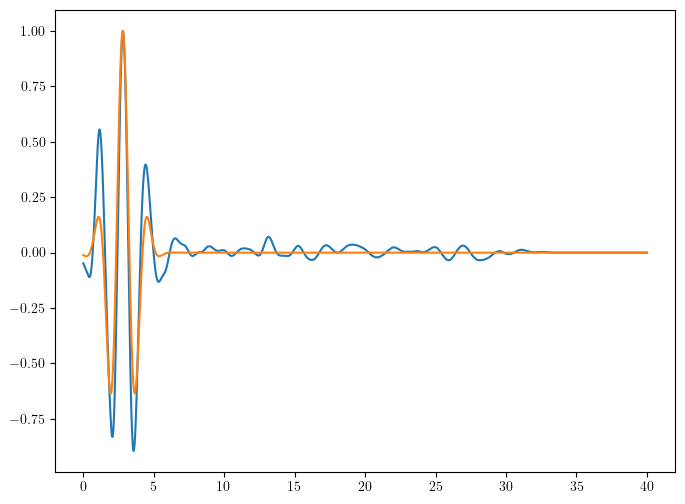

Estimated gather centroid frequency: 492.61 Hz, Wavelet length: 2.03 ms
Scale:  47.54216050967635 0.0010450215347037643 0.001325692661582848
Iter 0: Alpha = 141134.5762717834 Misfit = 1.0161e+05
Scale:  83.19285330944633 0.0010450215347037643 0.0010789032742090812
Iter 1: Alpha = 52356.29426465735 Misfit = 1.1257e+04
Scale:  86.55908931594372 0.0010450215347037643 0.001005489348854315
Iter 2: Alpha = 13615.951133115854 Misfit = 3.8795e+03
Scale:  124.92090939023511 0.0010450215347037643 0.0011922473206878337
Iter 3: Alpha = 58693.63675968161 Misfit = 2.6759e+03
Scale:  196.34350572896216 0.0010450215347037643 0.0010123885529886006
Iter 4: Alpha = 17252.9710003427 Misfit = 3.6768e+02


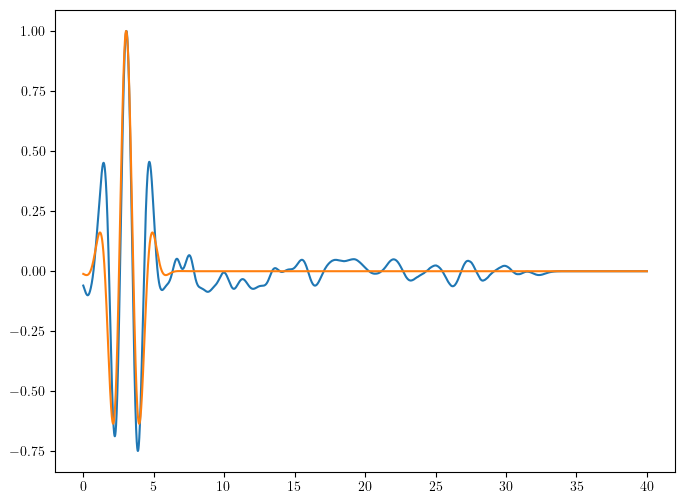

Estimated gather centroid frequency: 480.58 Hz, Wavelet length: 2.08 ms
Scale:  40.392840716320094 0.0008919012397758735 0.0011286697637716827
Iter 0: Alpha = 166166.38575718686 Misfit = 1.0676e+05
Scale:  72.5695720916008 0.0008919012397758735 0.0009649450522305026
Iter 1: Alpha = 60952.764589442886 Misfit = 1.0073e+04
Scale:  76.20935380892256 0.0008919012397758735 0.0008385438269698545
Iter 2: Alpha = 15248.8916720238 Misfit = 3.0499e+03
Scale:  112.9237685929912 0.0008919012397758735 0.0010160010155093402
Iter 3: Alpha = 62067.55531076748 Misfit = 2.0180e+03
Scale:  184.49914654638997 0.0008919012397758735 0.0008938064374942306
Iter 4: Alpha = 17755.479345941927 Misfit = 2.3796e+02


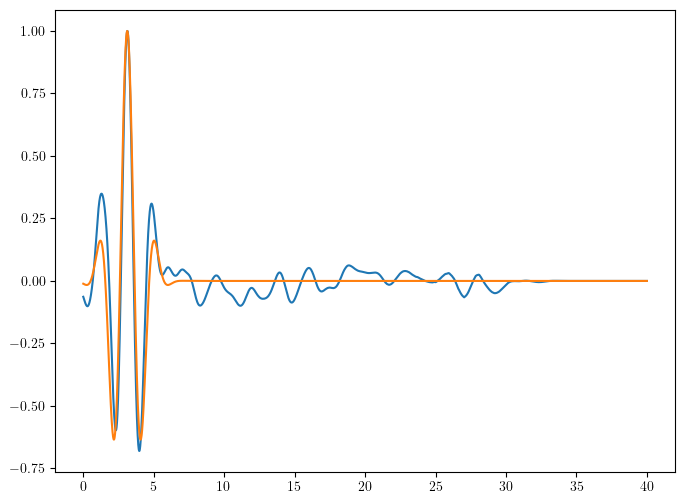

Estimated gather centroid frequency: 500.65 Hz, Wavelet length: 2.00 ms
Scale:  35.95164493506969 0.0006852912933891519 0.000848898134933038
Iter 0: Alpha = 236096.56590468073 Misfit = 9.8372e+04
Scale:  60.011520639621835 0.0006852912933891519 0.000699396939039319
Iter 1: Alpha = 52280.279033565814 Misfit = 1.0971e+04
Scale:  60.727975668560426 0.0006852912933891519 0.0006362018588150396
Iter 2: Alpha = 22824.570704700553 Misfit = 6.0555e+03
Scale:  80.82585917486912 0.0006852912933891519 0.0007725892729316594
Iter 3: Alpha = 92501.99041560816 Misfit = 4.4495e+03
Scale:  79.88540346532305 0.0006852912933891519 0.0005133062781547116
Iter 4: Alpha = 11617.522364825827 Misfit = 1.0235e+03


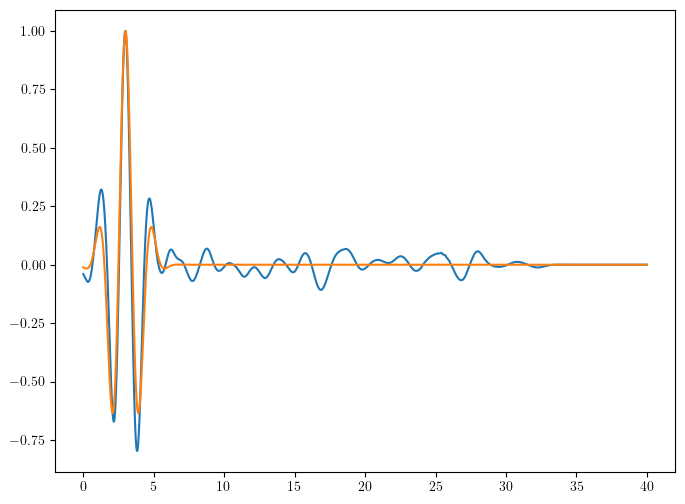

Estimated gather centroid frequency: 502.37 Hz, Wavelet length: 1.99 ms
Scale:  48.545033695318274 0.0007797258894887848 0.0009579162374743441
Iter 0: Alpha = 226895.41706041322 Misfit = 9.7702e+04
Scale:  71.719223087724 0.0007797258894887848 0.0007140267508495339
Iter 1: Alpha = 25219.387758349494 Misfit = 1.2731e+04
Scale:  84.94330366260708 0.0007797258894887848 0.0008153339121051291
Iter 2: Alpha = 37029.78744717489 Misfit = 9.5733e+03
Scale:  80.71903351588081 0.0007797258894887848 0.0007003965288166434
Iter 3: Alpha = 16813.398801692398 Misfit = 6.4410e+03
Scale:  106.33487856287752 0.0007797258894887848 0.0008771101450238452
Iter 4: Alpha = 71810.14703378313 Misfit = 5.1145e+03


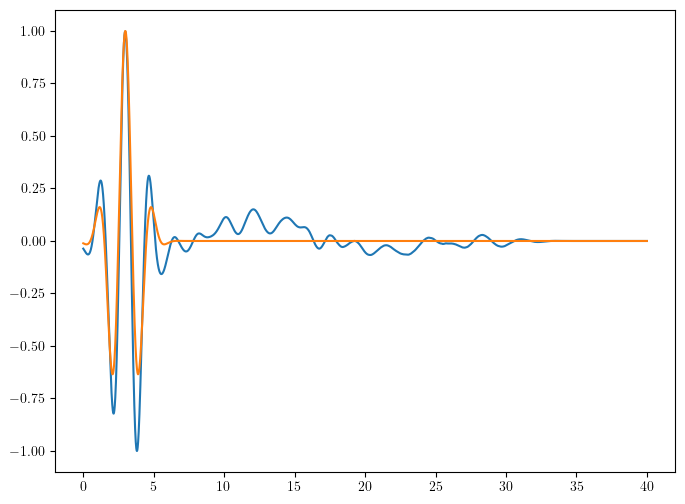

Estimated gather centroid frequency: 460.51 Hz, Wavelet length: 2.17 ms
Scale:  53.99516748999824 0.0008700145518229147 0.0010259798348953985
Iter 0: Alpha = 200859.87233938658 Misfit = 1.1627e+05
Scale:  71.23549335154624 0.0008700145518229147 0.0007633677357863599
Iter 1: Alpha = 18045.75958164181 Misfit = 1.7229e+04
Scale:  95.21196751189687 0.0008700145518229147 0.0009036542845974318
Iter 2: Alpha = 70926.98120517345 Misfit = 1.3749e+04
Scale:  74.7062327973455 0.0008700145518229147 0.0006670393607946163
Iter 3: Alpha = 11129.52809538066 Misfit = 5.9756e+03
Scale:  122.24590907520711 0.0008700145518229147 0.0009144409290565745
Iter 4: Alpha = 36551.34756448112 Misfit = 4.8098e+03


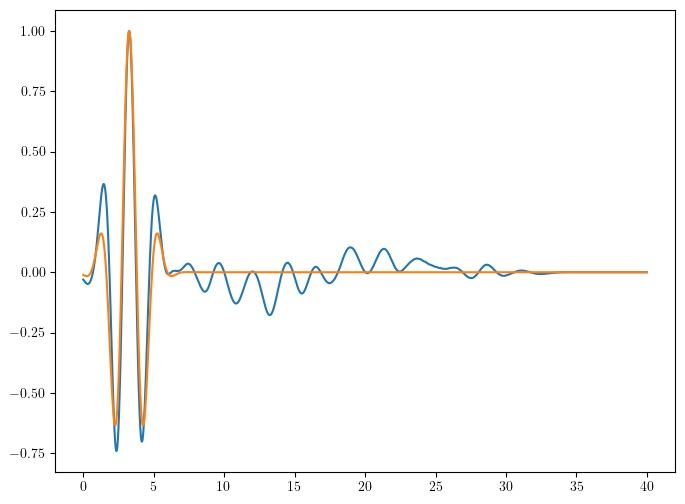

Estimated gather centroid frequency: 449.20 Hz, Wavelet length: 2.23 ms
Scale:  76.88207017025567 0.001330166451313628 0.001452447002496778
Iter 0: Alpha = 153283.18388814933 Misfit = 1.2220e+05
Scale:  87.16924514378503 0.001330166451313628 0.0010741575288805564
Iter 1: Alpha = 9818.814897908218 Misfit = 2.0192e+04
Scale:  127.84355250114758 0.001330166451313628 0.0011908019025256389
Iter 2: Alpha = 57141.69466329241 Misfit = 1.6892e+04
Scale:  108.08588141339838 0.001330166451313628 0.001165279996192693
Iter 3: Alpha = 7918.817124640312 Misfit = 7.1844e+03
Scale:  158.91725856005965 0.001330166451313628 0.0014123315215710387
Iter 4: Alpha = 26337.699688953016 Misfit = 6.0430e+03


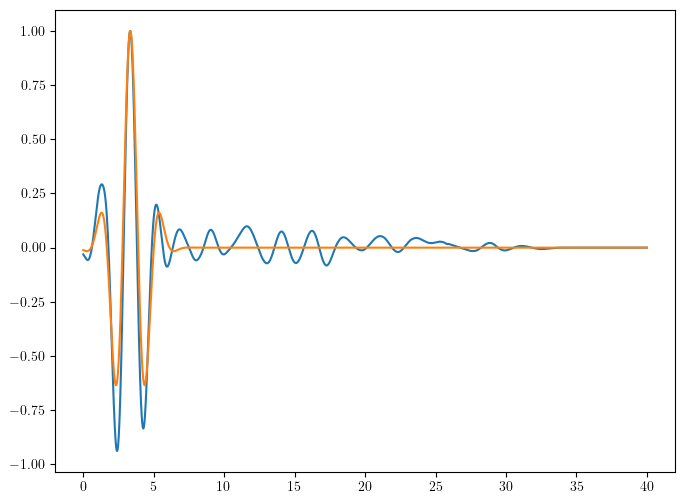

Estimated gather centroid frequency: 522.29 Hz, Wavelet length: 1.91 ms
Scale:  92.27425078416601 0.0014766052915748745 0.0016503705065950872
Iter 0: Alpha = 133279.48956755476 Misfit = 9.0391e+04
Scale:  100.17001582348084 0.0014766052915748745 0.0011218035772447004
Iter 1: Alpha = 6854.302102452615 Misfit = 1.3053e+04
Scale:  152.1831465386459 0.0014766052915748745 0.0013273279205819632
Iter 2: Alpha = 24275.776019576664 Misfit = 1.0993e+04
Scale:  132.4734805136671 0.0014766052915748745 0.0012392732318831218
Iter 3: Alpha = 6175.066592523083 Misfit = 7.0164e+03
Scale:  185.23881581232294 0.0014766052915748745 0.0015439100316013616
Iter 4: Alpha = 56585.77775905418 Misfit = 6.1025e+03


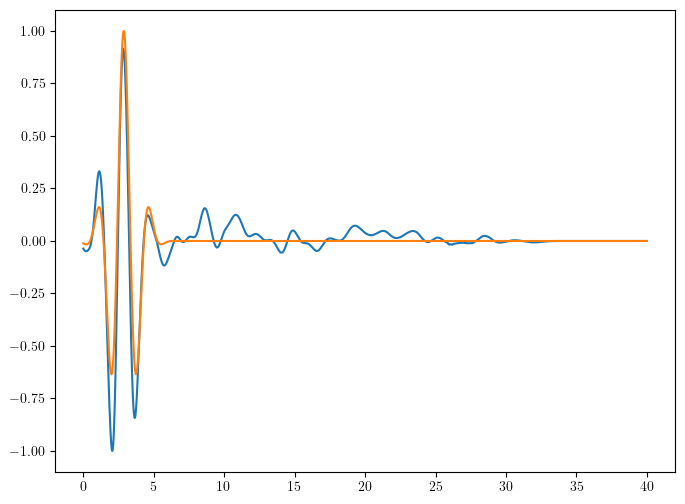

Estimated gather centroid frequency: 494.77 Hz, Wavelet length: 2.02 ms
Scale:  124.37946022385128 0.0026529344619124497 0.002657676905187107
Iter 0: Alpha = 63672.84025119017 Misfit = 1.0072e+05
Scale:  170.0059297114897 0.0026529344619124497 0.001876109781246511
Iter 1: Alpha = 5708.466299874295 Misfit = 1.2637e+04
Scale:  219.74803214650336 0.0026529344619124497 0.0024897032851124586
Iter 2: Alpha = 20678.827867553333 Misfit = 9.8471e+03
Scale:  180.63557389424048 0.0026529344619124497 0.0017098946883537032
Iter 3: Alpha = 3301.898245023772 Misfit = 4.0222e+03
Scale:  284.9009907315003 0.0026529344619124497 0.0024754400502945374
Iter 4: Alpha = 10560.594755049304 Misfit = 3.1781e+03


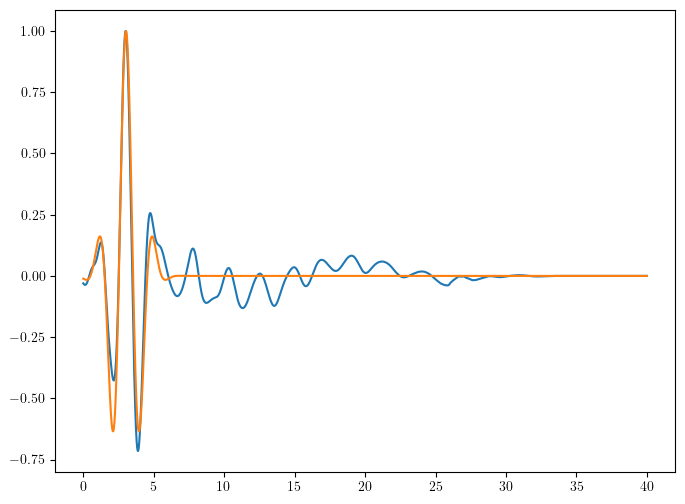

Estimated gather centroid frequency: 490.80 Hz, Wavelet length: 2.04 ms
Scale:  105.1450031059909 0.0024416723576065435 0.00257780976715036
Iter 0: Alpha = 61738.93220678403 Misfit = 1.0236e+05
Scale:  148.50628640564048 0.0024416723576065435 0.0018150723158192597
Iter 1: Alpha = 6291.27934483967 Misfit = 1.3292e+04
Scale:  186.58905691542802 0.0024416723576065435 0.0025593014112558735
Iter 2: Alpha = 17421.90264458103 Misfit = 1.0136e+04
Scale:  159.26329147129042 0.0024416723576065435 0.0016227015238582754
Iter 3: Alpha = 3594.790244739195 Misfit = 4.8551e+03
Scale:  241.3395337673995 0.0024416723576065435 0.002541395407164601
Iter 4: Alpha = 16340.815931850684 Misfit = 3.8391e+03


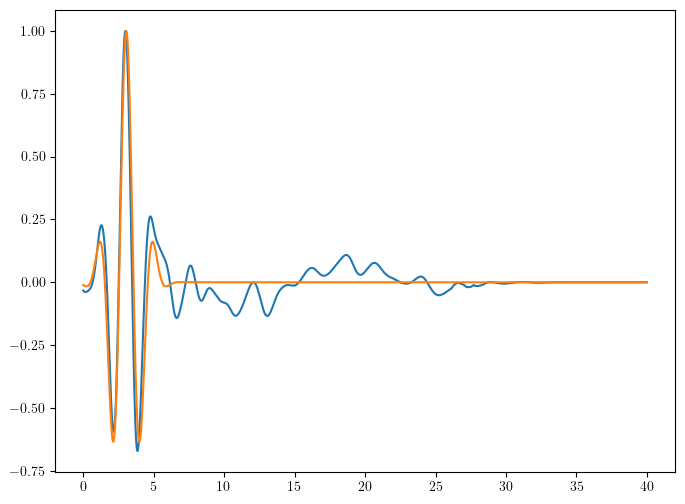

Estimated gather centroid frequency: 445.90 Hz, Wavelet length: 2.24 ms
Scale:  100.40941580634603 0.0028828404107425452 0.0026924046695189774
Iter 0: Alpha = 56339.83081066189 Misfit = 1.2401e+05
Scale:  137.4591632576858 0.0028828404107425452 0.0018027537979388726
Iter 1: Alpha = 5738.895371205917 Misfit = 1.6696e+04
Scale:  180.9215474909168 0.0028828404107425452 0.002829176646910174
Iter 2: Alpha = 19712.65694559261 Misfit = 1.2702e+04
Scale:  153.0516307397377 0.0028828404107425452 0.001566724324178794
Iter 3: Alpha = 3299.2012552373135 Misfit = 4.9245e+03
Scale:  243.47791291699474 0.0028828404107425452 0.0028454129028147378
Iter 4: Alpha = 11796.77519242347 Misfit = 3.8148e+03


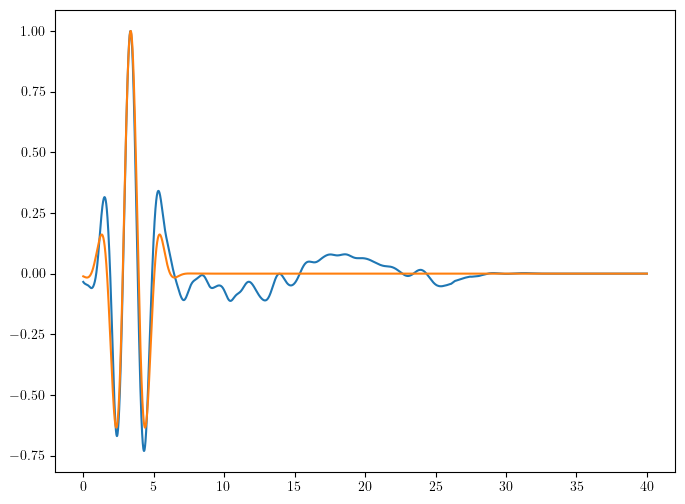

Estimated gather centroid frequency: 470.32 Hz, Wavelet length: 2.13 ms
Scale:  137.10765147463846 0.0032174516333866687 0.003014212565176525
Iter 0: Alpha = 43856.838219885474 Misfit = 1.1147e+05
Scale:  171.27543692282447 0.0032174516333866687 0.002316117428139923
Iter 1: Alpha = 3786.0297981859635 Misfit = 1.6964e+04
Scale:  236.82647026401483 0.0032174516333866687 0.0027147694442716764
Iter 2: Alpha = 22020.616051641737 Misfit = 1.3492e+04
Scale:  222.6926324147546 0.0032174516333866687 0.002258373902255117
Iter 3: Alpha = 2545.7736691876994 Misfit = 3.4062e+03
Scale:  339.64131766340813 0.0032174516333866687 0.0032144605581913713
Iter 4: Alpha = 8248.693094393353 Misfit = 2.6298e+03


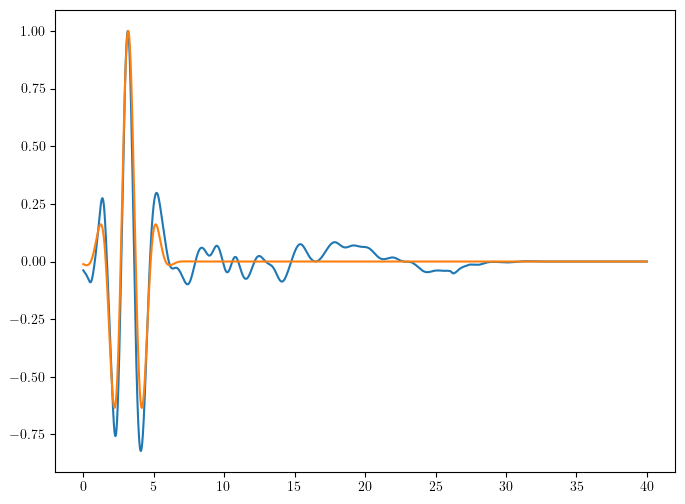

Estimated gather centroid frequency: 454.00 Hz, Wavelet length: 2.20 ms
Scale:  156.32828917405033 0.0033387723336963477 0.003933063279005686
Iter 0: Alpha = 39778.58514125772 Misfit = 1.1962e+05
Scale:  180.6649382307823 0.0033387723336963477 0.0029440216017035037
Iter 1: Alpha = 2988.9521125471856 Misfit = 1.9857e+04
Scale:  258.5261946743519 0.0033387723336963477 0.003743487192097297
Iter 2: Alpha = 18751.872529513483 Misfit = 1.6190e+04
Scale:  256.1020926422517 0.0033387723336963477 0.0038703013040897976
Iter 3: Alpha = 2789.865602047457 Misfit = 4.9159e+03
Scale:  355.89260291067126 0.0033387723336963477 0.0041317292686610255
Iter 4: Alpha = 6917.20882730903 Misfit = 3.7748e+03


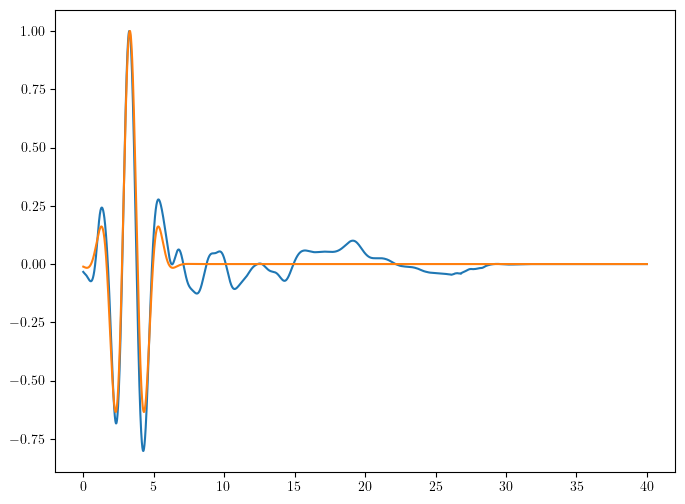

Estimated gather centroid frequency: 447.10 Hz, Wavelet length: 2.24 ms
Scale:  145.6931191342771 0.003440319160254994 0.0037002944510317972
Iter 0: Alpha = 46512.660751685944 Misfit = 1.2335e+05
Scale:  152.3460404115552 0.003440319160254994 0.002580467999100348
Iter 1: Alpha = 3009.951423677239 Misfit = 2.5667e+04
Scale:  218.91082383141494 0.003440319160254994 0.003263696305373283
Iter 2: Alpha = 11421.604746206558 Misfit = 2.1731e+04
Scale:  198.8248358928541 0.003440319160254994 0.0033658119141409637
Iter 3: Alpha = 2718.0324151083346 Misfit = 1.3595e+04
Scale:  265.1497346058461 0.003440319160254994 0.0037259083321660724
Iter 4: Alpha = 21243.67489017631 Misfit = 1.1762e+04


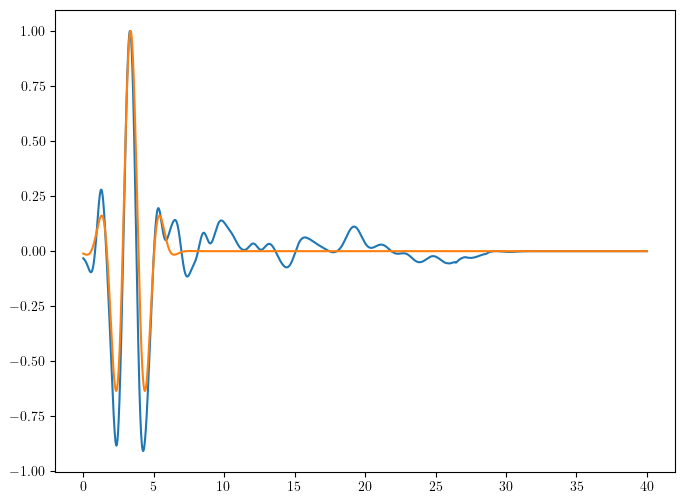

Estimated gather centroid frequency: 460.69 Hz, Wavelet length: 2.17 ms
Scale:  136.83971541316063 0.003227966953302141 0.003353634519155566
Iter 0: Alpha = 49989.422342872786 Misfit = 1.1618e+05
Scale:  148.4394390804409 0.003227966953302141 0.0023369096903712865
Iter 1: Alpha = 3432.0475308564473 Misfit = 2.3101e+04
Scale:  210.05414963717286 0.003227966953302141 0.002777774459702577
Iter 2: Alpha = 17557.25165150282 Misfit = 1.9426e+04
Scale:  184.47451396757143 0.003227966953302141 0.0031469613276100036
Iter 3: Alpha = 2835.6953926182337 Misfit = 9.6076e+03
Scale:  256.55030737412346 0.003227966953302141 0.0034649957406990557
Iter 4: Alpha = 11562.361714410063 Misfit = 8.1888e+03


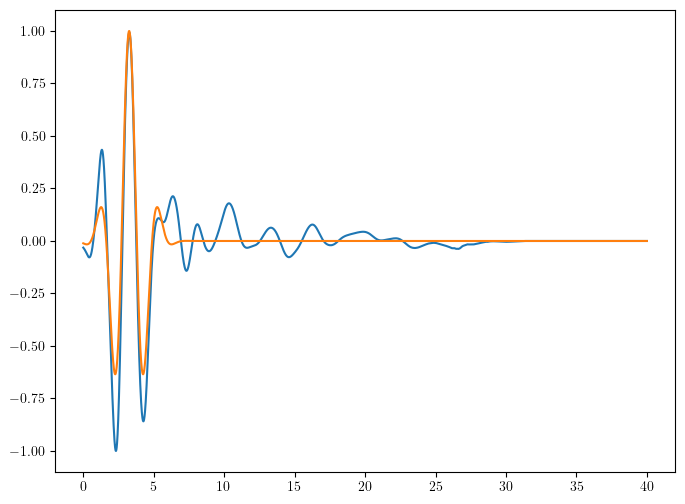

Estimated gather centroid frequency: 473.27 Hz, Wavelet length: 2.11 ms
Scale:  92.97831281554026 0.002187992783390937 0.002439333091556729
Iter 0: Alpha = 58581.01451545703 Misfit = 1.1008e+05
Scale:  123.06830622503317 0.002187992783390937 0.001582422969640837
Iter 1: Alpha = 7169.526348744359 Misfit = 1.9482e+04
Scale:  153.12579429123258 0.002187992783390937 0.0021905912433281415
Iter 2: Alpha = 15535.347609914785 Misfit = 1.5044e+04
Scale:  133.36161455021002 0.002187992783390937 0.0015279428521432952
Iter 3: Alpha = 4477.021268280158 Misfit = 8.8743e+03
Scale:  193.9638163442988 0.002187992783390937 0.002295202224524541
Iter 4: Alpha = 34556.36549225732 Misfit = 7.1714e+03


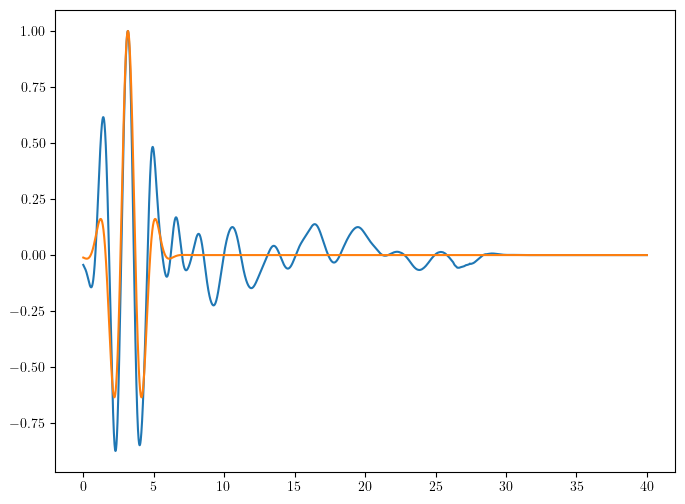

Estimated gather centroid frequency: 435.61 Hz, Wavelet length: 2.30 ms
Scale:  94.51347321849425 0.002762766604372041 0.002781516456247056
Iter 0: Alpha = 45246.81356143372 Misfit = 1.2994e+05
Scale:  131.6854205568343 0.002762766604372041 0.0019818468959344427
Iter 1: Alpha = 10712.895591413797 Misfit = 2.8400e+04
Scale:  140.76707756760092 0.002762766604372041 0.0024000651972367498
Iter 2: Alpha = 7583.2873590631425 Misfit = 1.9350e+04
Scale:  164.05547232043142 0.002762766604372041 0.002279561520700076
Iter 3: Alpha = 11926.604581478327 Misfit = 1.4597e+04
Scale:  155.92614887579418 0.002762766604372041 0.002311497537018255
Iter 4: Alpha = 4622.15633622169 Misfit = 9.1919e+03


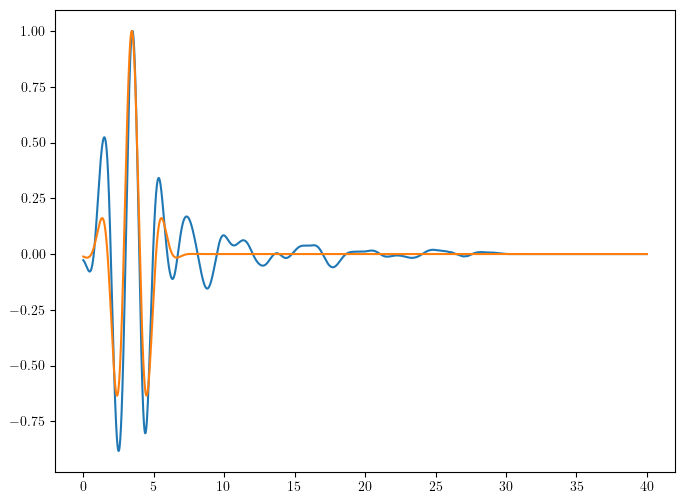

Estimated gather centroid frequency: 458.66 Hz, Wavelet length: 2.18 ms
Scale:  136.28767865685347 0.0030157840881981355 0.0033431952348036195
Iter 0: Alpha = 39306.05542469454 Misfit = 1.1721e+05
Scale:  191.30790282524563 0.0030157840881981355 0.0023701961581955506
Iter 1: Alpha = 6657.855873233023 Misfit = 2.1214e+04
Scale:  219.76530467970684 0.0030157840881981355 0.0030243955278113793
Iter 2: Alpha = 7553.003488036943 Misfit = 1.5146e+04
Scale:  226.89905332077043 0.0030157840881981355 0.0024606119743118605
Iter 3: Alpha = 4989.595853413643 Misfit = 1.0480e+04
Scale:  268.381622375813 0.0030157840881981355 0.003215586931537049
Iter 4: Alpha = 7945.676266148124 Misfit = 7.8247e+03


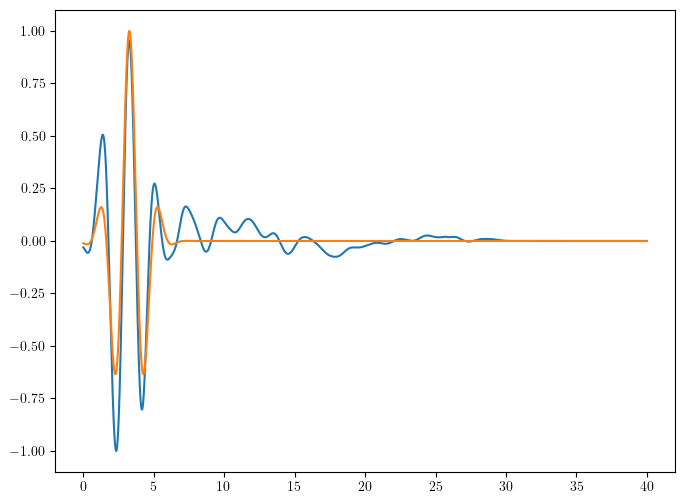

Estimated gather centroid frequency: 426.96 Hz, Wavelet length: 2.34 ms
Scale:  146.3796100989568 0.0034064898278410045 0.003945399864697411
Iter 0: Alpha = 38150.1280626609 Misfit = 1.3525e+05
Scale:  210.57997012069586 0.0034064898278410045 0.002584610918196722
Iter 1: Alpha = 6416.415968155394 Misfit = 2.0659e+04
Scale:  250.1809788336299 0.0034064898278410045 0.0032311140380815984
Iter 2: Alpha = 7810.628245576061 Misfit = 1.4031e+04
Scale:  255.59095161623674 0.0034064898278410045 0.002537633787638509
Iter 3: Alpha = 4473.842628684858 Misfit = 8.7870e+03
Scale:  320.44247314647043 0.0034064898278410045 0.0033296963688005357
Iter 4: Alpha = 9063.817148190223 Misfit = 6.3120e+03


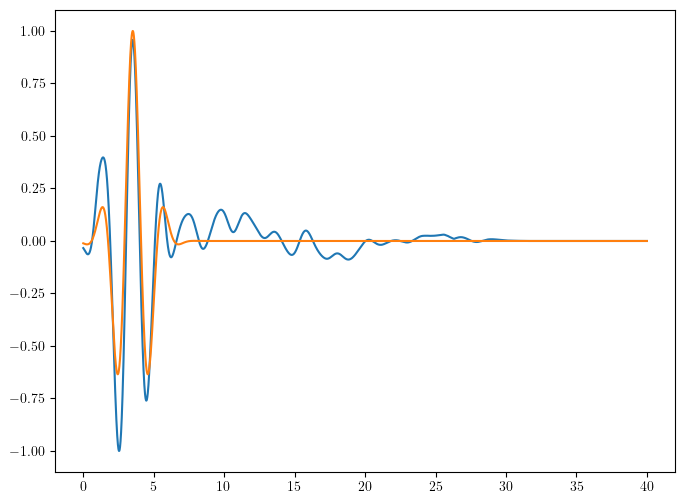

Estimated gather centroid frequency: 466.34 Hz, Wavelet length: 2.14 ms
Scale:  102.97684551203308 0.0022998668593423774 0.002505129767960074
Iter 0: Alpha = 67203.38605226192 Misfit = 1.1338e+05
Scale:  149.7315817457231 0.0022998668593423774 0.0016690053605725147
Iter 1: Alpha = 9645.796453226463 Misfit = 1.6036e+04
Scale:  181.20039613523727 0.0022998668593423774 0.0020886459549031506
Iter 2: Alpha = 13726.88948925903 Misfit = 1.1303e+04
Scale:  176.50338164463005 0.0022998668593423774 0.001629357643168811
Iter 3: Alpha = 6268.984655192097 Misfit = 6.9698e+03
Scale:  234.98973552643687 0.0022998668593423774 0.0021423070583371654
Iter 4: Alpha = 22966.094431206606 Misfit = 5.2517e+03


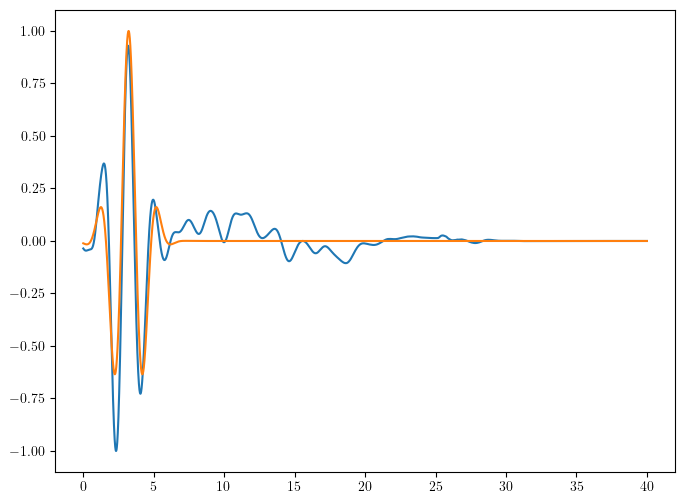

Estimated gather centroid frequency: 419.40 Hz, Wavelet length: 2.38 ms
Scale:  65.12012810825316 0.0015452683968785106 0.0017222625877351002
Iter 0: Alpha = 112349.87539688543 Misfit = 1.4018e+05
Scale:  88.92159105155177 0.0015452683968785106 0.0011210727442649544
Iter 1: Alpha = 15854.76634969846 Misfit = 2.1575e+04
Scale:  112.80756800105424 0.0015452683968785106 0.0014118697130046745
Iter 2: Alpha = 36376.865217548795 Misfit = 1.5335e+04
Scale:  104.18670631864056 0.0015452683968785106 0.0010244714995546109
Iter 3: Alpha = 9065.808965831999 Misfit = 7.1595e+03
Scale:  151.26766990177646 0.0015452683968785106 0.0013924906432932838
Iter 4: Alpha = 55250.1108953914 Misfit = 5.3972e+03


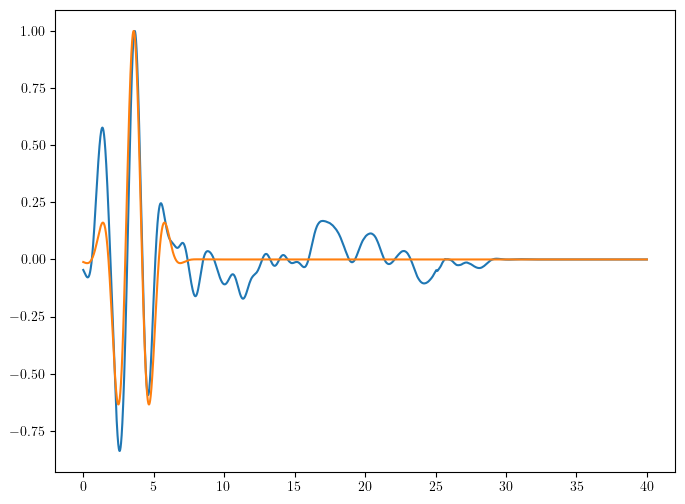

Estimated gather centroid frequency: 456.41 Hz, Wavelet length: 2.19 ms
Scale:  55.137972532163076 0.001090675278737242 0.0012047409766133943
Iter 0: Alpha = 175985.72453559752 Misfit = 1.1837e+05
Scale:  72.66606181164191 0.001090675278737242 0.000798382070402423
Iter 1: Alpha = 18808.73656832909 Misfit = 1.6369e+04
Scale:  98.81016006579823 0.001090675278737242 0.0010037308501431312
Iter 2: Alpha = 76066.58072112434 Misfit = 1.2174e+04
Scale:  92.11546082323359 0.001090675278737242 0.0007278982243811081
Iter 3: Alpha = 11112.764297879383 Misfit = 3.6717e+03
Scale:  141.51276971182506 0.001090675278737242 0.0010572541460911256
Iter 4: Alpha = 41908.10755952725 Misfit = 2.7641e+03


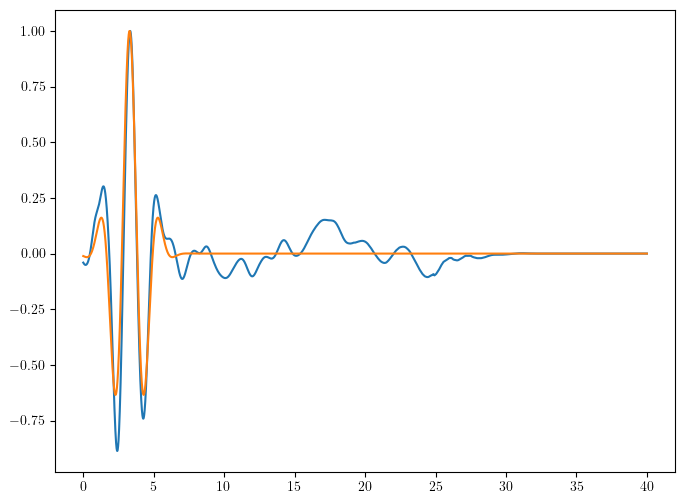

Estimated gather centroid frequency: 432.07 Hz, Wavelet length: 2.31 ms
Scale:  66.53273903631727 0.0011214087782576581 0.0013576858145138108
Iter 0: Alpha = 158152.55152418293 Misfit = 1.3208e+05
Scale:  79.28639635255571 0.0011214087782576581 0.0009151718136802068
Iter 1: Alpha = 18408.656506453783 Misfit = 2.6500e+04
Scale:  108.77325498361984 0.0011214087782576581 0.0011099180745610237
Iter 2: Alpha = 91147.37139955327 Misfit = 2.0548e+04
Scale:  109.57173054191502 0.0011214087782576581 0.0009085623701316452
Iter 3: Alpha = 13569.438780361463 Misfit = 6.0302e+03
Scale:  155.9834441365348 0.0011214087782576581 0.0012150517893176787
Iter 4: Alpha = 43268.174851667776 Misfit = 4.5955e+03


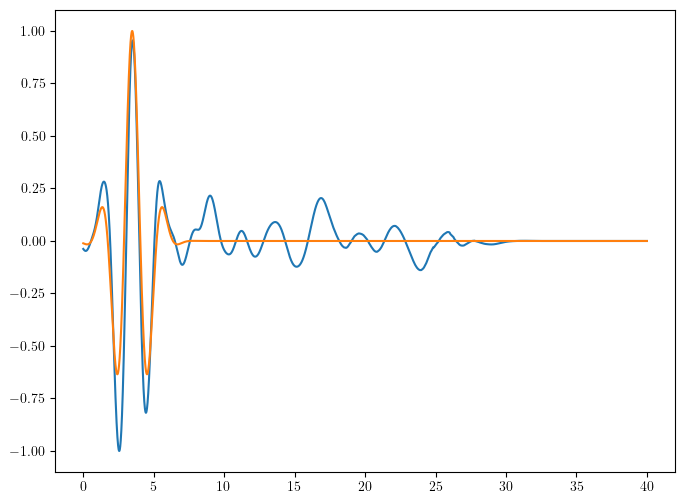

Estimated gather centroid frequency: 441.27 Hz, Wavelet length: 2.27 ms
Scale:  38.73832549182245 0.0006268109058502738 0.0007239765905076568
Iter 0: Alpha = 319402.0905922203 Misfit = 1.2663e+05
Scale:  44.5966235311874 0.0006268109058502738 0.0004564797212267513
Iter 1: Alpha = 34721.61502370249 Misfit = 2.4279e+04
Scale:  63.61948065342502 0.0006268109058502738 0.0005930011205567845
Iter 2: Alpha = 179519.5266166112 Misfit = 1.8774e+04
Scale:  66.58695185363695 0.0006268109058502738 0.0005977482275606647
Iter 3: Alpha = 34948.19307392028 Misfit = 5.3088e+03
Scale:  96.89864188708563 0.0006268109058502738 0.000675952313218696
Iter 4: Alpha = 127261.6466668176 Misfit = 3.7494e+03


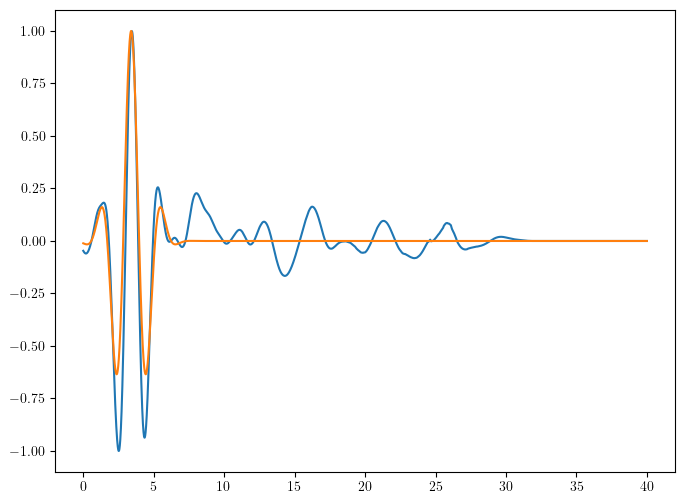

In [31]:
max_iter = 5
beta = 1e-7
for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = AcousticWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.995), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.995))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Alpha = {alpha} Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"../adjoint_wavelets/wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"../adjoint_wavelets/wavelet_scale_{k}.npy", scale_factor)